# Customer Segmentation & Behavioral Analysis 
## *BY Gheffari Nour El Houda* 
### Marketing Campaign Dataset – Exploratory Data Analysis & Clustering

---

## Business Context

Customer segmentation is the process of dividing a customer base into groups of individuals who share similar characteristics.  
This allows businesses to better understand their customers, personalize marketing strategies, improve engagement, and increase conversion rates.

In this project, we address the problem of **customer segmentation for a retail store** using **unsupervised machine learning**.  
Since no labels exist in the dataset, clustering techniques are used to discover hidden customer groups based on demographic and behavioral patterns.

The results of this analysis will be used to generate **actionable business recommendations** for targeted marketing and customer relationship management.

---

## Main Questions We Aim to Answer

To structure the analysis, this project is organized around **three key questions**:

---

- Who are our customers?
- What defines each customer segment?
- How do segments differ in spending, engagement, and responsiveness?
- How can marketing strategies be tailored to each segment?
- How do age, income, family structure, and time as a client vary across the population?
- What does spending behavior look like overall?


## Project Objective

The main objectives of this project are to:

- Clean and prepare the data for analysis  
- Explore customer behavior and relationships between features  
- Reduce dimensionality for better visualization and clustering  
- Identify meaningful customer segments using unsupervised learning  
- Translate analytical findings into **business recommendations**

---

## Methodology Overview

This analysis follows the full clustering workflow:

1. Data Cleaning & Feature Engineering  
2. Exploratory Data Analysis (Univariate, Bivariate, Multivariate)  
3. Encoding & Scaling  
4. Dimensionality Reduction (PCA, t-SNE)  
5. Clustering (K-Means)  
6. Cluster Profiling & Business Insights  

---

*By the end of this notebook, we will have a clear understanding of who the customers are, how they differ, and how the business can leverage these insights to improve marketing performance.*

# 1. Data Loading & Environment Setup


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd   
from scipy import stats                                                                 
from pandas.plotting import parallel_coordinates
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [554]:
df=pd.read_csv("C:\\Users\\nourg\\Documents\\VS_code\\EDA\\marketing_campaign.csv",sep="\t")

In [555]:
print("Number of datapoints:", len(df))
print("Number of features:", len(df.columns))

Number of datapoints: 2240
Number of features: 29


In [556]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


### Features:

#### People

ID: Customer's unique identifier

Year_Birth: Customer's birth year

Education: Customer's education level

Marital_Status: Customer's marital status

Income: Customer's yearly household income

Kidhome: Number of children in customer's household

Teenhome: Number of teenagers in customer's household

Dt_Customer: Date of customer's enrollment with the company

Recency: Number of days since customer's last purchase

Complain: 1 if the customer complained in the last 2 years, 0 otherwise

#### Products

MntWines: Amount spent on wine in last 2 years

MntFruits: Amount spent on fruits in last 2 years

MntMeatProducts: Amount spent on meat in last 2 years

MntFishProducts: Amount spent on fish in last 2 years

MntSweetProducts: Amount spent on sweets in last 2 years

MntGoldProds: Amount spent on gold in last 2 years

#### Promotion

NumDealsPurchases: Number of purchases made with a discount

AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

#### Place

NumWebPurchases: Number of purchases made through the company’s website

NumCatalogPurchases: Number of purchases made using a catalogue

NumStorePurchases: Number of purchases made directly in stores

NumWebVisitsMonth: Number of visits to company’s website in the last month

---
# 2. Memory Optimization
---
Data types were optimized to reduce memory footprint, improving efficiency for later transformations.


In [557]:
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of DataFrame before optimization is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [558]:
df = reduce_mem_usage(df)

Memory usage of DataFrame before optimization is 0.50 MB
Memory usage after optimization is: 0.11 MB
Decreased by 78.0%


---

# 3. Initial Data Exploration

---

In [559]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   2240 non-null   int16   
 1   Year_Birth           2240 non-null   int16   
 2   Education            2240 non-null   category
 3   Marital_Status       2240 non-null   category
 4   Income               2216 non-null   float32 
 5   Kidhome              2240 non-null   int8    
 6   Teenhome             2240 non-null   int8    
 7   Dt_Customer          2240 non-null   category
 8   Recency              2240 non-null   int8    
 9   MntWines             2240 non-null   int16   
 10  MntFruits            2240 non-null   int16   
 11  MntMeatProducts      2240 non-null   int16   
 12  MntFishProducts      2240 non-null   int16   
 13  MntSweetProducts     2240 non-null   int16   
 14  MntGoldProds         2240 non-null   int16   
 15  NumDealsPurchases    

In [560]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.250000,25173.076172,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [561]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [562]:
df.duplicated().sum()

np.int64(0)

In [563]:
missing = df['Income'].isna().sum()
total = len(df)
available = total - missing

In [564]:
labels = ['Available', 'Missing']
values = [available, missing]

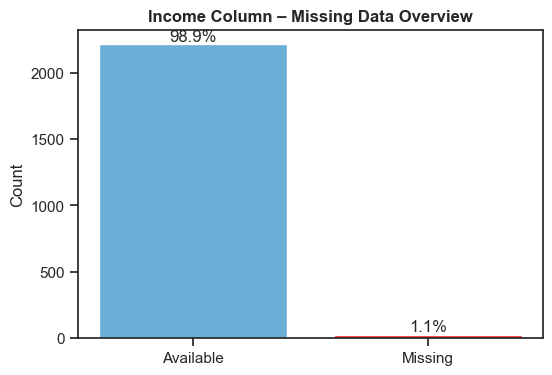

In [565]:
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=["#6BAED6", "#FF1F1F"])

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val/total*100:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title('Income Column – Missing Data Overview', weight='bold')
plt.ylabel('Count')
plt.show()

**Insight:**  
We observe that missing values in the *Income* column represent only **1.1%** of the data.  
Since this proportion is very small, removing these rows will not significantly affect the overall analysis, so we can safely drop them.


---
# 4. Data Cleaning
---

In [566]:
df = df.dropna()

In [567]:
print("Number of unique values in Z_CostContact column:", df['Z_CostContact'].nunique())
print("Number of unique values in Z_Revenue column:", df["Z_Revenue"].nunique())

Number of unique values in Z_CostContact column: 1
Number of unique values in Z_Revenue column: 1


In [568]:
df.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

**Insight:**  
We also observe that the columns *Z_CostContact* and *Z_Revenue* each contain only **one unique value**.  
Since these features have no variability, they do not provide any useful information for analysis or modeling, and therefore we remove them from the dataset.


In [569]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

dates = []

for i in df["Dt_Customer"]:
    i = i.date()
    dates.append(i)  

print(f"Newest customer's enrolment date is {max(dates)}")
print(f"Oldest customer's enrolment date is {min(dates)}")

Newest customer's enrolment date is 2014-06-29
Oldest customer's enrolment date is 2012-07-30


---
# 5. Feature Engineering
---

Calculate the age of each customer

In [570]:
df['Age'] = 2013 - df['Year_Birth']

 Calculate the number of days each customer has been with the company 

In [571]:
df['Dt_Customer'] = pd.to_datetime(df.Dt_Customer, format="%d-%m-%Y")
latest_date = df['Dt_Customer'].max()
df['Days_is_client'] = (latest_date - df['Dt_Customer']).dt.days

 Standardize 'Marital_Status' into 2 broader groups

In [573]:
df['Marital_Status'] = df['Marital_Status'].replace(['Married', 'Together'], 'Partner')
df['Marital_Status'] = df['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd'], 'Single')

Standardize 'Education' into 3 broader groups

In [574]:
df['Education'] = df['Education'].replace(['PhD', 'Master'], 'Postgraduate')  
df['Education'] = df['Education'].replace(['2n Cycle', 'Graduation'], 'Graduate')
df['Education'] = df['Education'].replace(['Basic'], 'Undergraduate')

 Combined the number of children and teenagers into a single feature to represent the total number of dependents in a household.

In [576]:
df['Kids'] = df['Kidhome'] + df['Teenhome']

 Aggregated spending across all product categories to capture each customer’s total expenditure.

In [577]:
df['Expenses'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

 Summed all accepted marketing campaigns to measure overall customer responsiveness to promotions.


In [578]:
df['TotalAcceptedCmp'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5']

 Combined all purchase channels to represent the total number of transactions made by each customer.


In [579]:
df['TotalNumPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

In [580]:
data = df.copy()
df = df[['Age', 'Education', 'Marital_Status', 'Income', 'Kids', 'Days_is_client', 'Recency', 'Expenses', 
                 'TotalNumPurchases', 'TotalAcceptedCmp', 'Complain', 'Response']]

In [581]:
df.head()

,Age,Education,Marital_Status,Income,Kids,Days_is_client,Recency,Expenses,TotalNumPurchases,TotalAcceptedCmp,Complain,Response
0,56,Graduate,Single,58138.0,0,663,58,1617,25,0,0,1
1,59,Graduate,Single,46344.0,2,113,38,27,6,0,0,0
2,48,Graduate,Partner,71613.0,0,312,26,776,21,0,0,0
3,29,Graduate,Partner,26646.0,1,139,26,53,8,0,0,0
4,32,Postgraduate,Partner,58293.0,1,161,94,422,19,0,0,0


In [582]:
binary_columns = [col for col in df.columns if df[col].nunique() == 2]

In [583]:
categorical_columns = [col for col in df.columns if 2 < df[col].nunique() < 10]

In [584]:
numerical_columns = [col for col in df.select_dtypes(include=['number']).columns if col not in binary_columns + categorical_columns]

After feature engineering and data cleaning, the original columns used to create new features were removed, and only the newly engineered features were retained to avoid redundancy and simplify the dataset.


---
# 6. Outlier Detection & Removal
---

In [585]:
df[numerical_columns].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
Age,2216.0,44.180,11.986,17.0,36.0,43.0,54.0,120.0
Income,2216.0,52247.254,25173.076,1730.0,35303.0,51381.5,68522.0,666666.0
Days_is_client,2216.0,353.521,202.435,0.0,180.0,355.5,529.0,699.0
Recency,2216.0,49.013,28.948,0.0,24.0,49.0,74.0,99.0
Expenses,2216.0,607.075,602.900,5.0,69.0,396.5,1048.0,2525.0
TotalNumPurchases,2216.0,14.881,7.671,0.0,8.0,15.0,21.0,44.0


In [586]:
z_scores = pd.DataFrame(stats.zscore(df[numerical_columns]), columns=numerical_columns)

In [587]:
display(z_scores.describe().round(3).T)

,count,mean,std,min,25%,50%,75%,max
Age,2216.0,0.0,1.0,-2.268,-0.683,-0.098,0.820,6.327
Income,2216.0,0.0,1.0,-2.007,-0.673,-0.034,0.647,24.413
Days_is_client,2216.0,-0.0,1.0,-1.747,-0.857,0.010,0.867,1.707
Recency,2216.0,-0.0,1.0,-1.693,-0.864,-0.000,0.863,1.727
Expenses,2216.0,0.0,1.0,-0.999,-0.893,-0.349,0.732,3.182
TotalNumPurchases,2216.0,-0.0,1.0,-1.940,-0.897,0.016,0.798,3.797


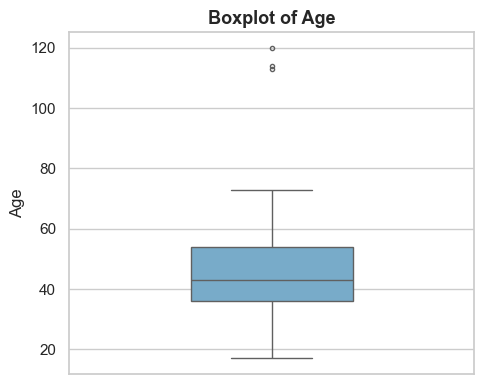

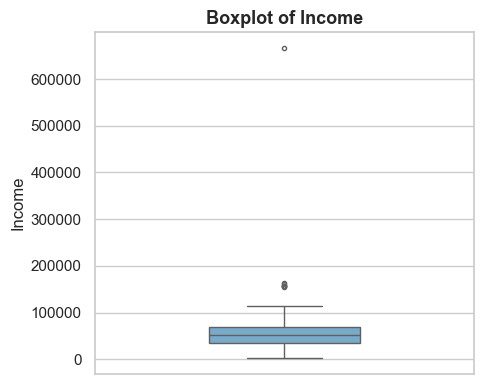

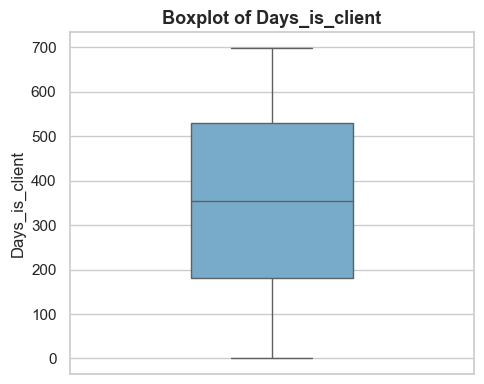

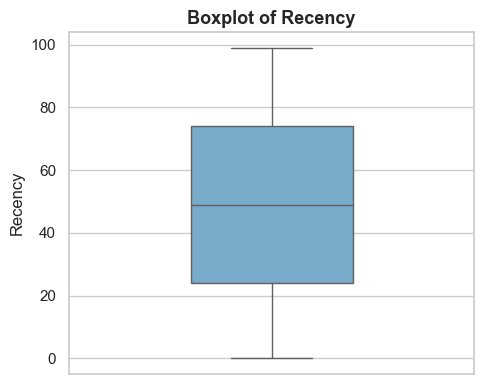

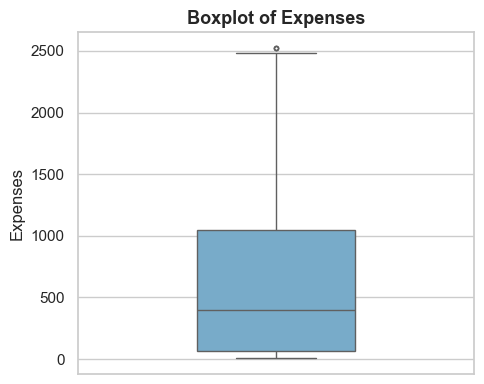

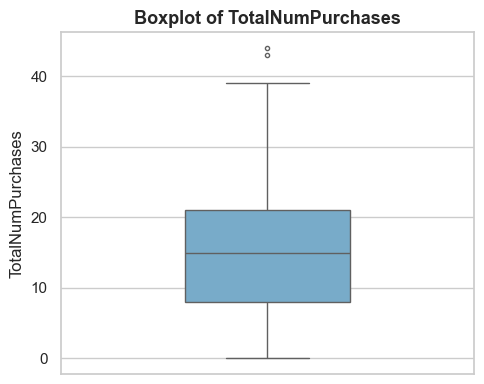

In [588]:
sns.set_style("whitegrid")  

for col in numerical_columns:
    plt.figure(figsize=(5, 4))
    
    sns.boxplot(
        y=df[col],
        color="#6BAED6",
        width=0.4,
        fliersize=3
    )
    
    plt.title(f"Boxplot of {col}", fontsize=13, weight="bold")
    plt.ylabel(col)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

After plotting the boxplots, we observed the presence of outliers in the **Age** and **Income** features. To better understand their distributions and assess the impact of these extreme values, we proceeded to visualize their histograms.


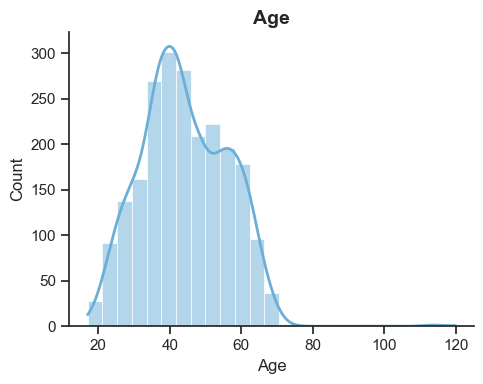

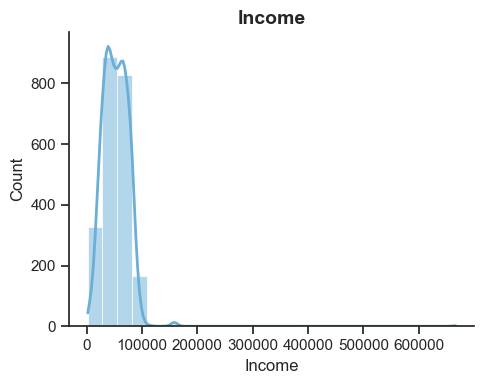

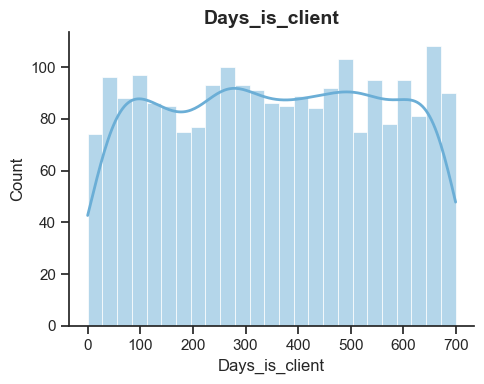

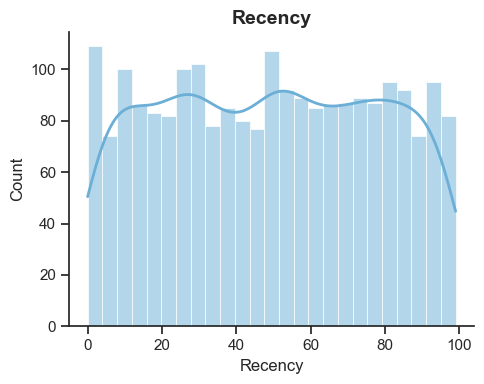

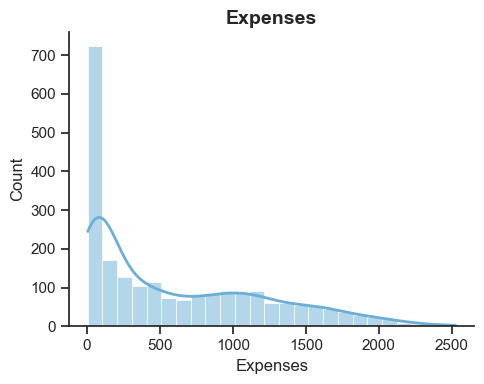

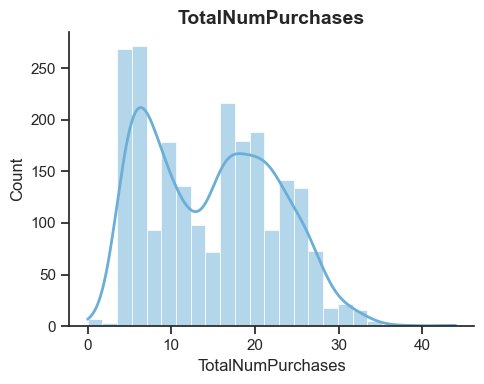

In [589]:
sns.set_theme(style="ticks")

for col in numerical_columns:
    plt.figure(figsize=(5, 4))
    
    sns.histplot(
        df[col].dropna(),
        bins=25,
        kde=True,
        color="#6BAED6",
        linewidth=0.5,
        line_kws={'linewidth': 2}
    )
   
    sns.despine()
    plt.title(col, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


In fact, both **Income** and **Age** show slight skewness in their distributions, which further indicates the presence of outliers and extreme values in these features.


---
# 7. Outlier Detection & Removal
---

To remove outliers, we first excluded values with a **z-score greater than 3** and then applied the **IQR method** to remove any remaining extreme values.


In [590]:
outliers = z_scores[(np.abs(z_scores) > 3).any(axis=1)]
outliers.shape

(18, 6)

In [591]:
df = df.drop(outliers.index)

In [592]:
def remove_outliers(data: pd.DataFrame, column: str) -> pd.Series:
    q3, q1 = np.nanpercentile(data[column], [75, 25])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    data = data[(data[column] > lower_bound) & (data[column] < upper_bound)]

    return data

In [593]:
for col in numerical_columns:
    df = remove_outliers(df, col)

---
# 8. Univariate Analysis
---

After outlier removal, we can perform **univariate analysis** more cleanly, as the distributions are now more reliable and easier to interpret.


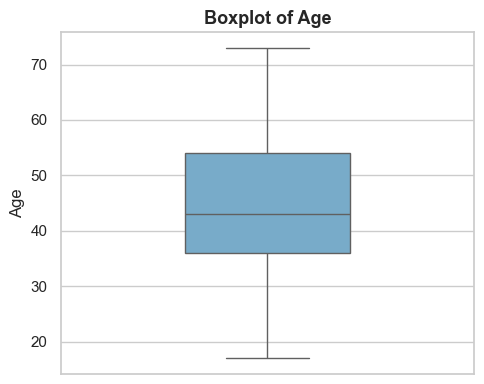

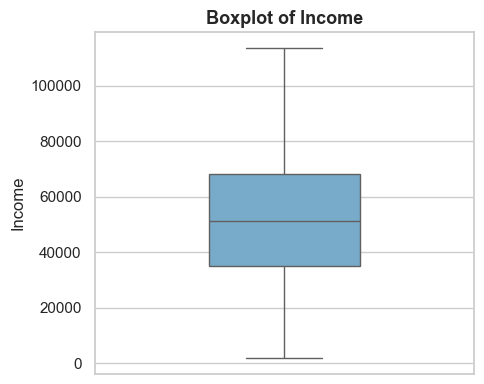

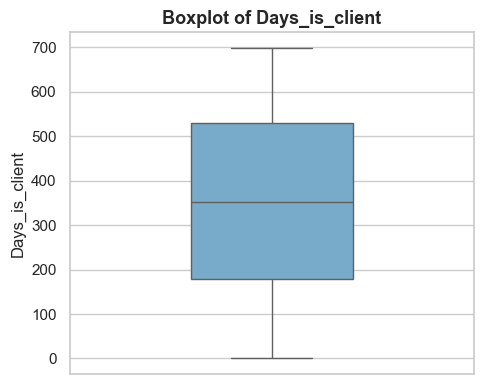

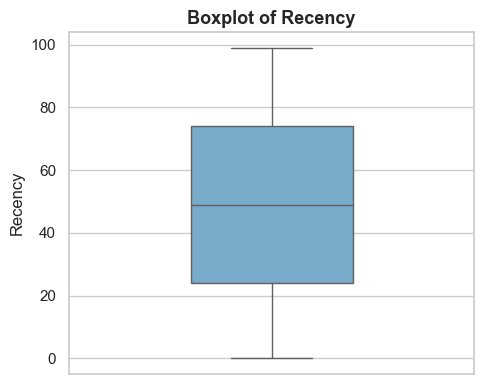

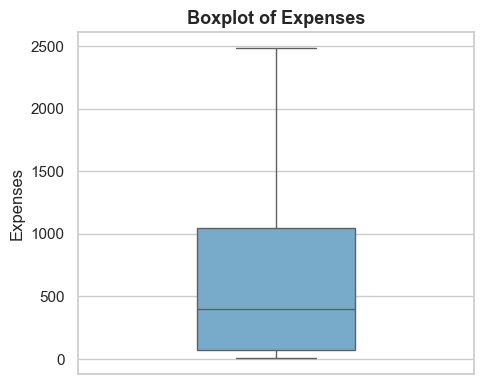

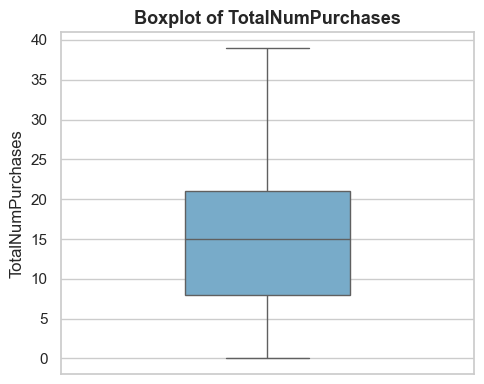

In [594]:
sns.set_style("whitegrid")  

for col in numerical_columns:
    plt.figure(figsize=(5, 4))
    
    sns.boxplot(
        y=df[col],
        color="#6BAED6",
        width=0.4,
        fliersize=3
    )
    
    plt.title(f"Boxplot of {col}", fontsize=13, weight="bold")
    plt.ylabel(col)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

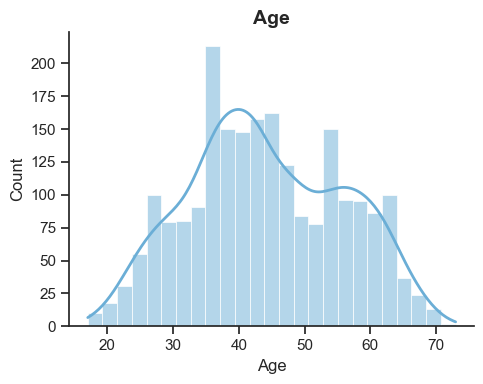

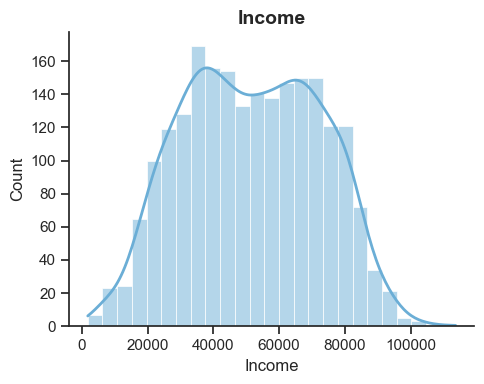

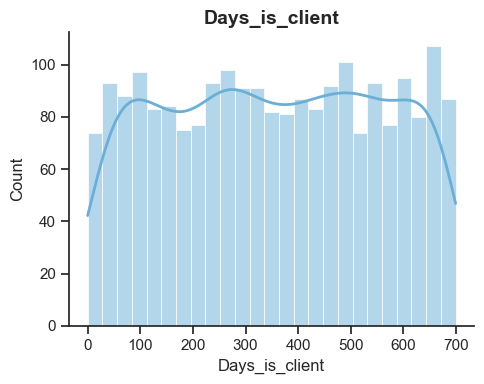

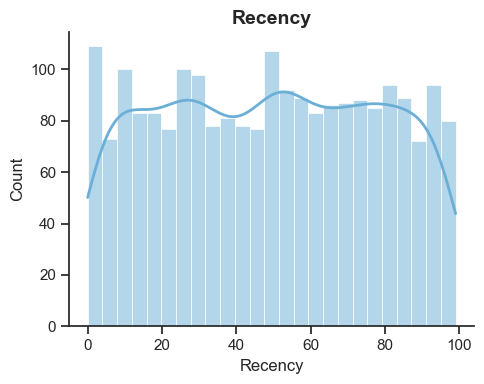

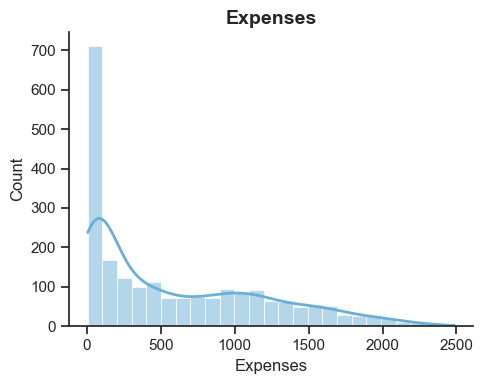

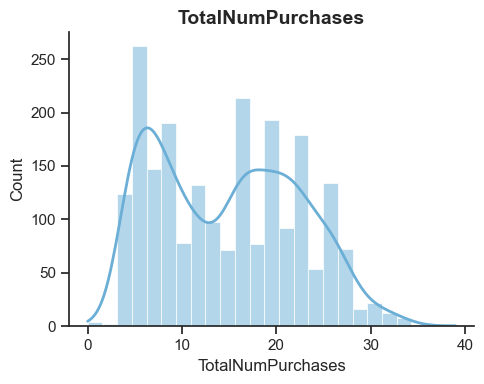

In [595]:
sns.set_theme(style="ticks")

for col in numerical_columns:
    plt.figure(figsize=(5, 4))
    
    sns.histplot(
        df[col].dropna(),
        bins=25,
        kde=True,
        color="#6BAED6",
        linewidth=0.5,
        line_kws={'linewidth': 2}
    )
   
    sns.despine()
    plt.title(col, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


**Key Findings from Numerical Visualizations:**  

**Income and Age Distribution:** After removing outliers, income follows a roughly normal distribution, suggesting that most customers earn around the average income, with fewer customers earning significantly more or less.  

**Days as Client & Recency:** Both features exhibit a fairly uniform distribution, indicating that customers have been with the company for varying lengths of time and have interacted recently across a wide range of periods.  

**Expenses Distribution:** Expenses show an exponential distribution, meaning that most customers have lower spending, with spending rapidly decreasing as amounts increase.  

**Total Number of Purchases:** This feature follows a binomial-like distribution, reflecting common purchasing behaviors among customers, such as making a specific number of purchases.


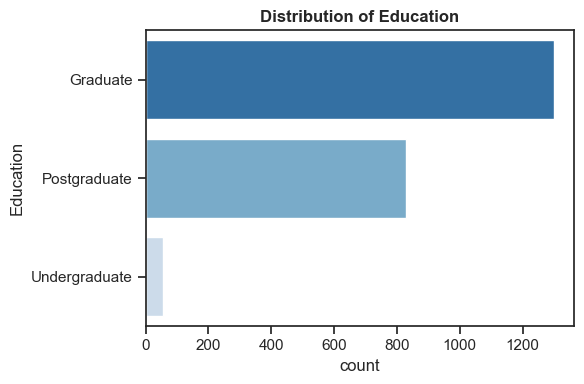

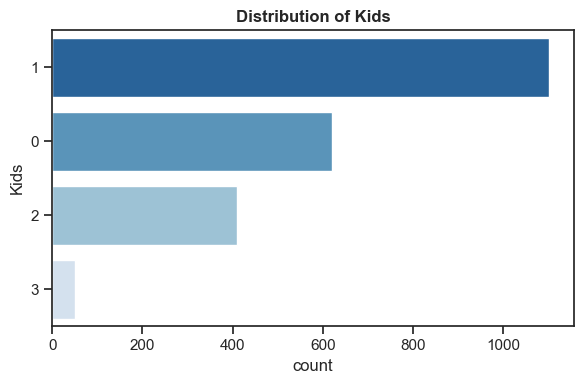

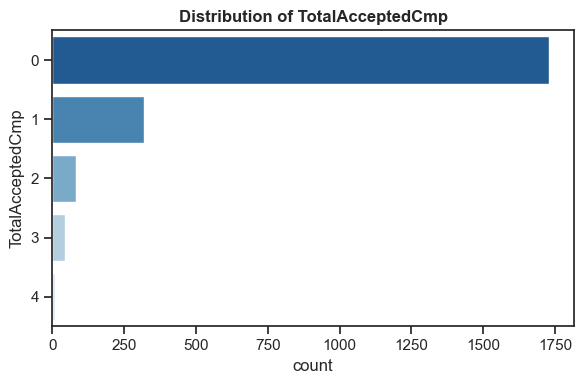

In [596]:
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette="Blues_r")
    plt.title(f"Distribution of {col}", weight="bold")
    plt.tight_layout()
    plt.show()


**Key Findings from Categorical and Binary Feature Visualizations:**  

**Education:** Most customers have a graduate-level education.  

**Kids:** The majority of customers have either no children or just one child.  

**Total Accepted Campaigns:** Most customers have never accepted any marketing offers.


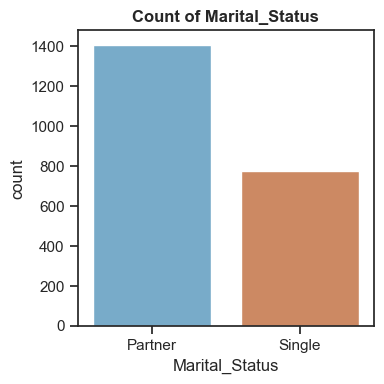

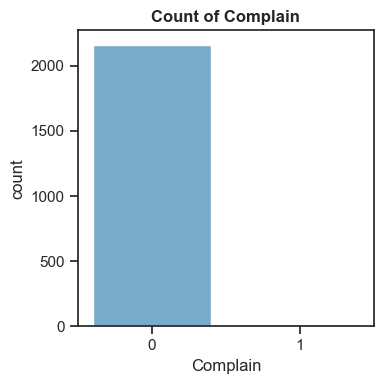

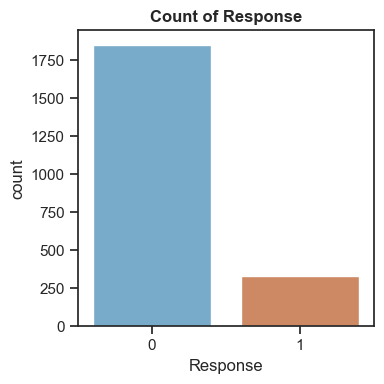

In [597]:
for col in binary_columns:
    plt.figure(figsize=(4, 4))
    sns.countplot(x=df[col], palette=["#6BAED6", "#DD8452"])
    plt.title(f"Count of {col}", weight="bold")
    plt.tight_layout()
    plt.show()


**Key Findings from Binary Feature Visualizations:**  

**Marital Status:** Most customers have a partner.  

**Complain:** The majority of customers have never lodged a complaint.


**Initial Customer Profile (Univariate Analysis):**  

Based on the distributions of numerical, categorical, and binary features:  
- Most customers are graduates.  
- Most have no kids or only one child.  
- Most have a partner.  
- The majority have never accepted marketing offers.  
- Most customers have never lodged a complaint.  

This provides an initial understanding of the customer base before proceeding to multivariate analysis and clustering.


## 8. Bivariate Analysis


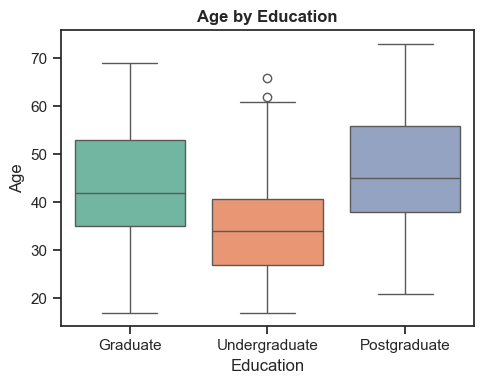

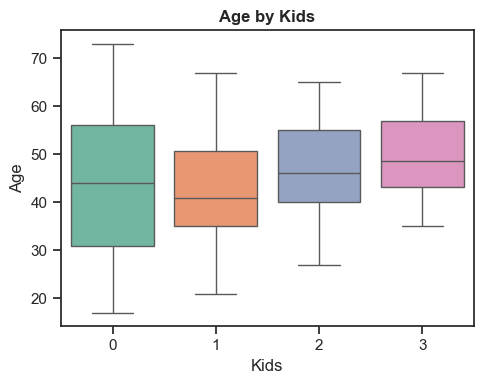

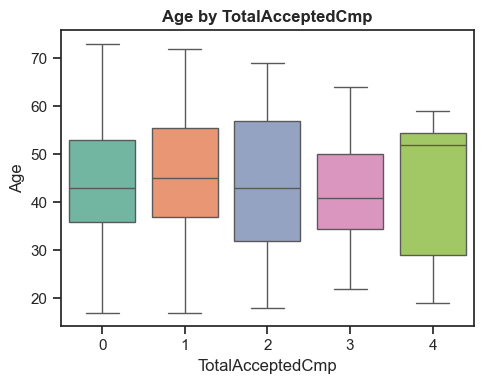

In [598]:
for cat_col in categorical_columns:
        plt.figure(figsize=(5, 4))
        sns.boxplot(x=df[cat_col], y=df["Age"], palette="Set2")
        plt.title(f"Age by {cat_col}", weight="bold")
        plt.tight_layout()
        plt.show()


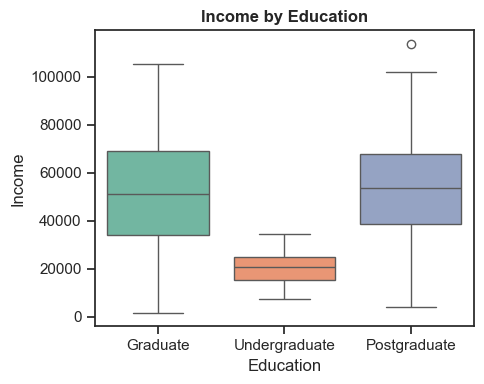

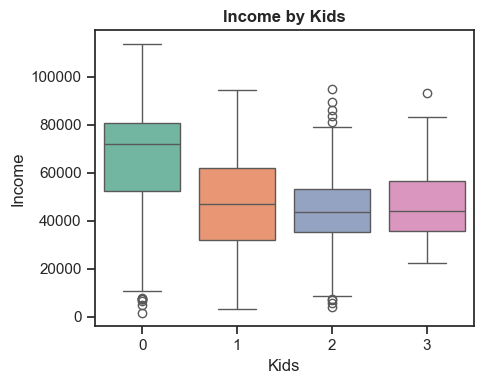

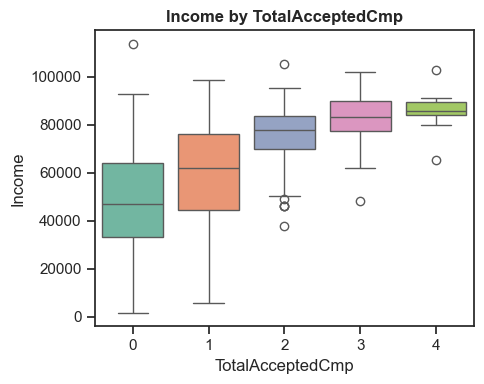

In [599]:
for cat_col in categorical_columns:
        plt.figure(figsize=(5, 4))
        sns.boxplot(x=df[cat_col], y=df["Income"], palette="Set2")
        plt.title(f"Income by {cat_col}", weight="bold")
        plt.tight_layout()
        plt.show()

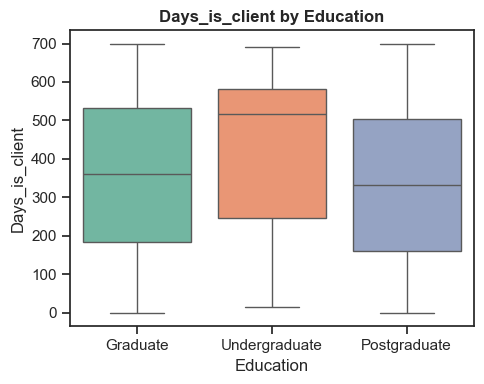

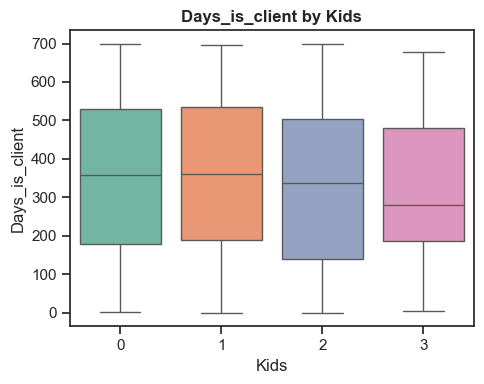

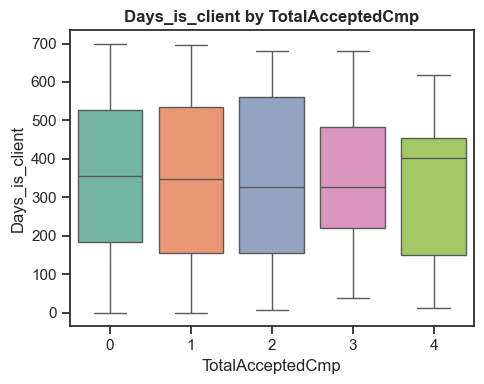

In [600]:
for cat_col in categorical_columns:
        plt.figure(figsize=(5, 4))
        sns.boxplot(x=df[cat_col], y=df["Days_is_client"], palette="Set2")
        plt.title(f"Days_is_client by {cat_col}", weight="bold")
        plt.tight_layout()
        plt.show()

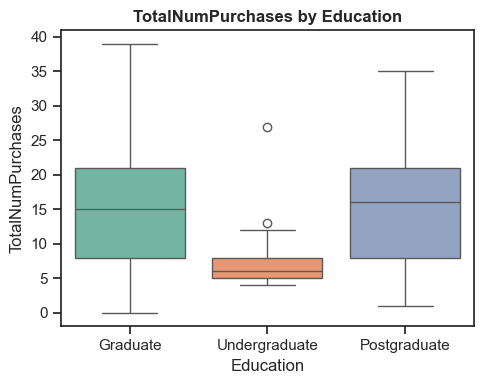

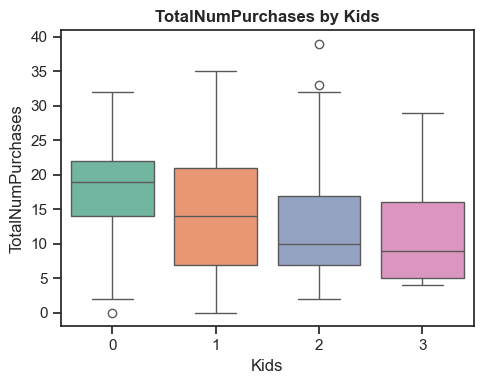

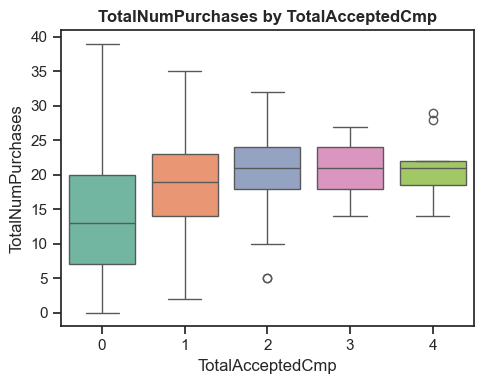

In [601]:
for cat_col in categorical_columns:
        plt.figure(figsize=(5, 4))
        sns.boxplot(x=df[cat_col], y=df["TotalNumPurchases"], palette="Set2")
        plt.title(f"TotalNumPurchases by {cat_col}", weight="bold")
        plt.tight_layout()
        plt.show()

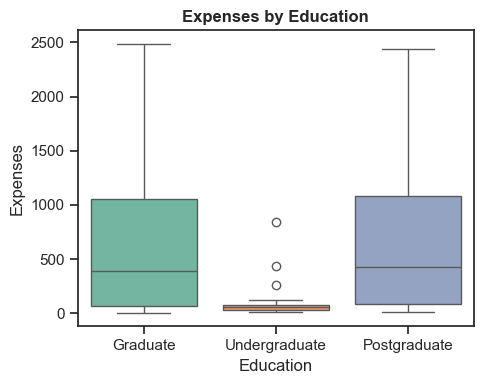

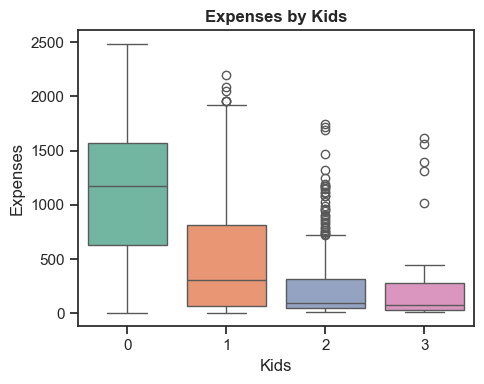

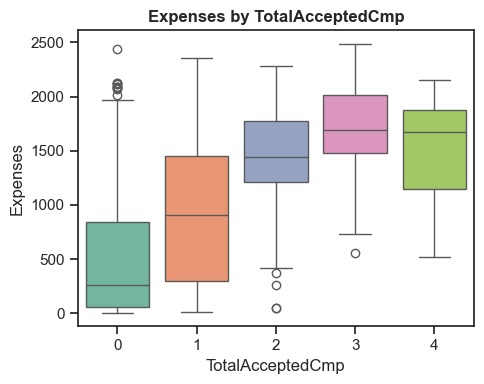

In [602]:
for cat_col in categorical_columns:
        plt.figure(figsize=(5, 4))
        sns.boxplot(x=df[cat_col], y=df["Expenses"], palette="Set2")
        plt.title(f"Expenses by {cat_col}", weight="bold")
        plt.tight_layout()
        plt.show()

**Customer Profiles by Education Level:**  

- **Graduate customers:** Most have one child or no children.  
- **Undergraduate customers:** Tend to have the fewest children overall.  
- **Postgraduate customers:** Most have either zero or one child.  
- **Offer acceptance:** Graduate and postgraduate customers rarely accept promotional offers.  
- **Marital status:** Most graduate and postgraduate customers have a partner.  


---
# 9. Feature Encoding 
---

**Feature Encoding:**  

- One-hot encoding was applied to categorical features because they have a limited number of categories. This allows the model to use these features effectively in clustering and analysis.


In [609]:
df_encoded = pd.get_dummies(df, columns=categorical_columns + ['Marital_Status'], drop_first=True, dtype=int)

In [610]:
df_encoded.head().T

,0,1,2,3,4
Age,56.0,59.0,48.0,29.0,32.0
Income,58138.0,46344.0,71613.0,26646.0,58293.0
Days_is_client,663.0,113.0,312.0,139.0,161.0
Recency,58.0,38.0,26.0,26.0,94.0
Expenses,1617.0,27.0,776.0,53.0,422.0
TotalNumPurchases,25.0,6.0,21.0,8.0,19.0
Complain,0.0,0.0,0.0,0.0,0.0
Response,1.0,0.0,0.0,0.0,0.0
Education_Undergraduate,0.0,0.0,0.0,0.0,0.0
Education_Postgraduate,0.0,0.0,0.0,0.0,1.0


---
# 10. Multivariate Analysis
---

In [611]:
palette_2 = ["#4E79A7", "#F28E2B"]
palette_3 = ["#4C72B0", "#55A868", "#C44E52"]
palette_4 = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

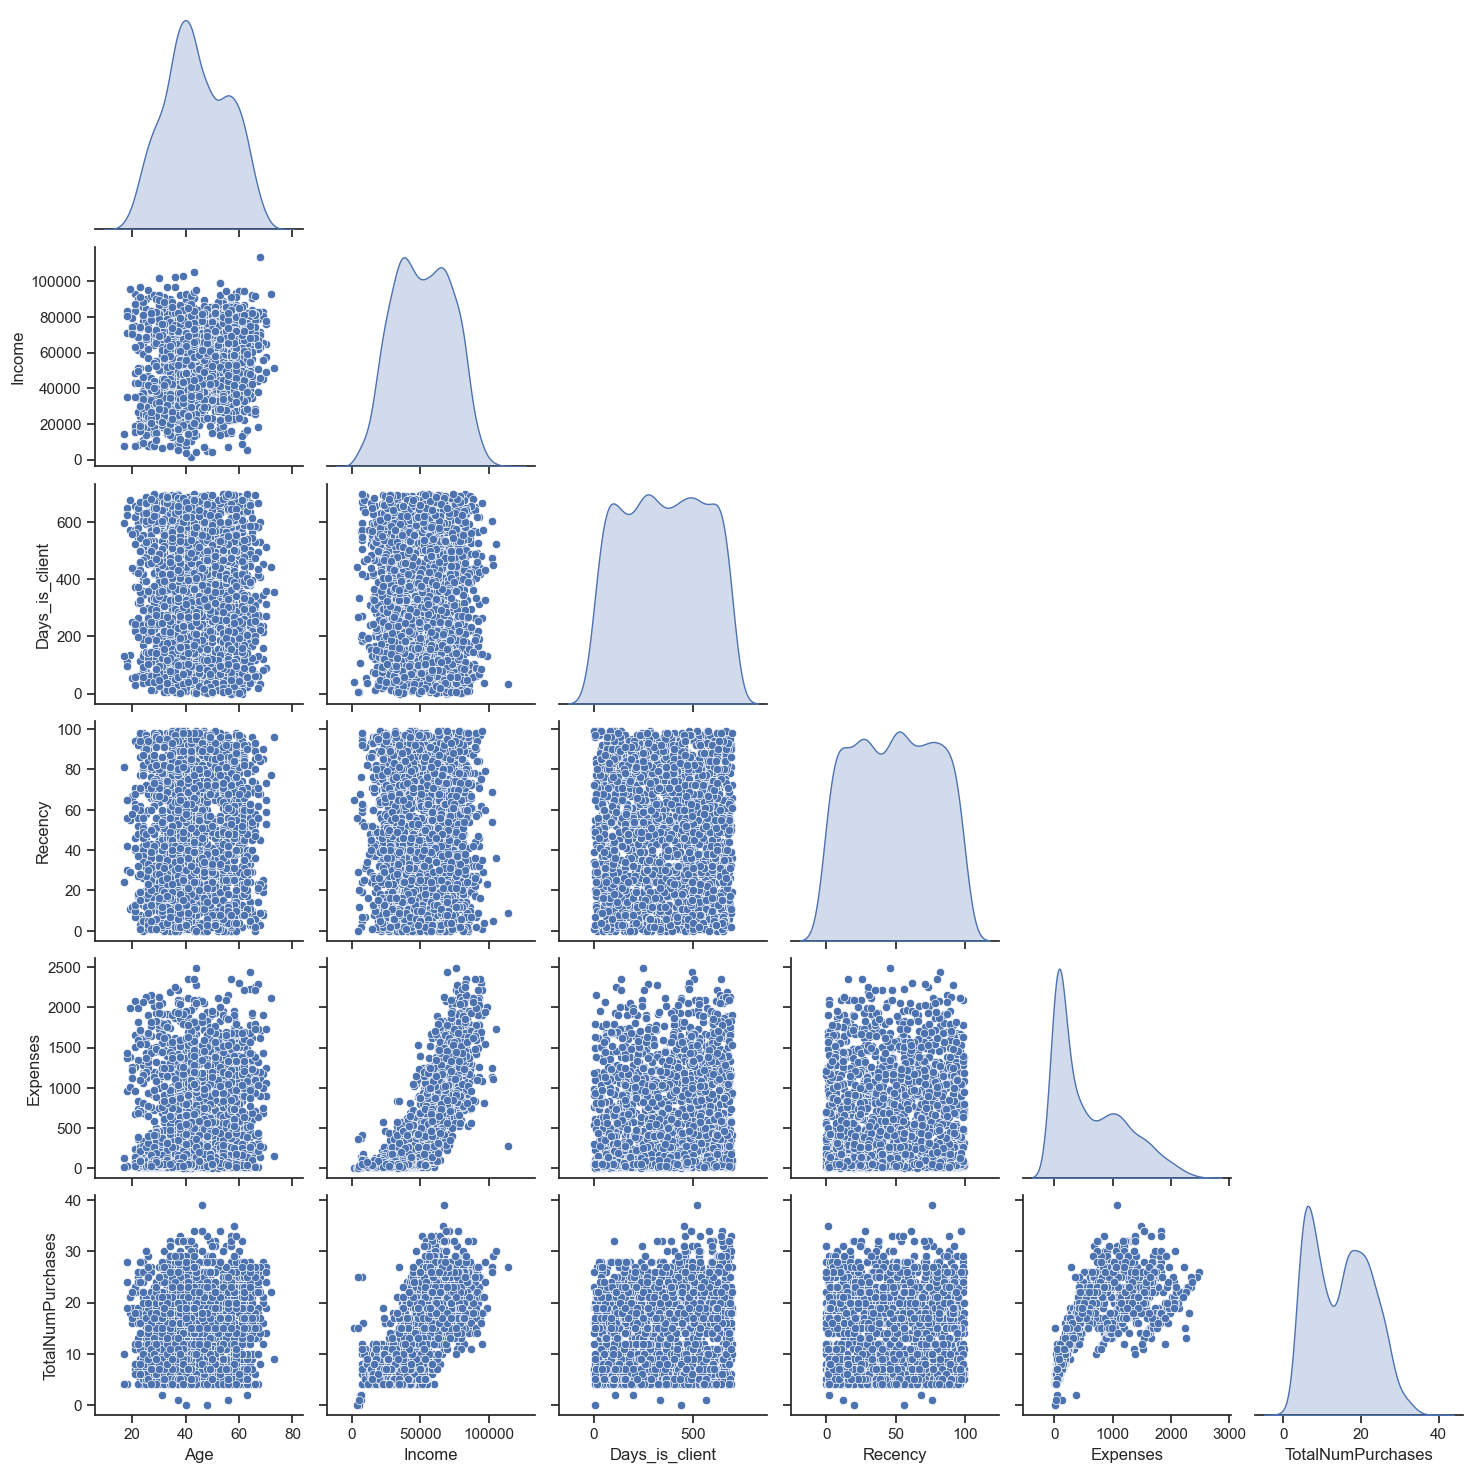

In [612]:
sns.pairplot(df[numerical_columns], diag_kind="kde", corner=True)
plt.show()

**Pairplot Insights:**  

The pairplot of numerical features reveals the following patterns:  
- **Income and Total Number of Purchases:** Positive trend – customers with higher income tend to make more purchases.  
- **Expenses and Total Number of Purchases:** Positive trend – customers who spend more also tend to purchase more often.  
- **Income and Expenses:** Positive trend – higher-income customers generally have higher expenses.  

Overall, the scatterplots show clear linear relationships among these three variables, highlighting the impact of income on


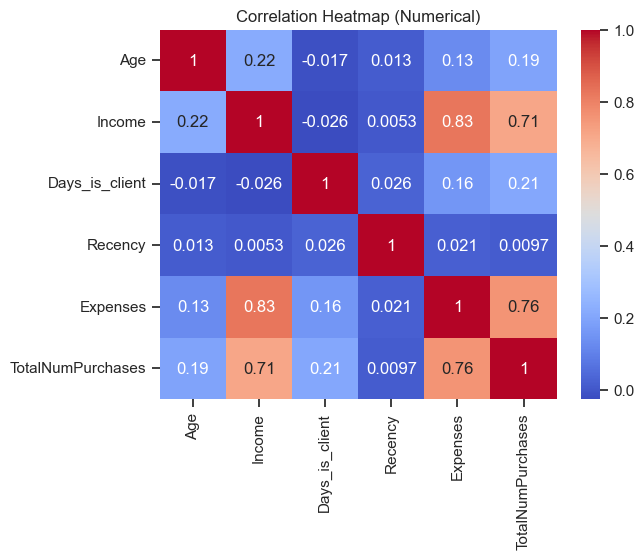

In [613]:
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical)")
plt.show()


**Correlation Heatmap Insights:**  

The correlation heatmap confirms our observations from the pairplot, showing strong positive correlations among key features:  
- **Income & Expenses:** 0.83 – higher-income customers tend to spend more.  
- **Income & Total Number of Purchases:** 0.71 – higher-income customers make more purchases.  
- **Expenses & Total Number of Purchases:** 0.76 – customers who spend more also tend to purchase more frequently.  

These correlations highlight the close relationship between customer income, spending, and purchasing behavior.


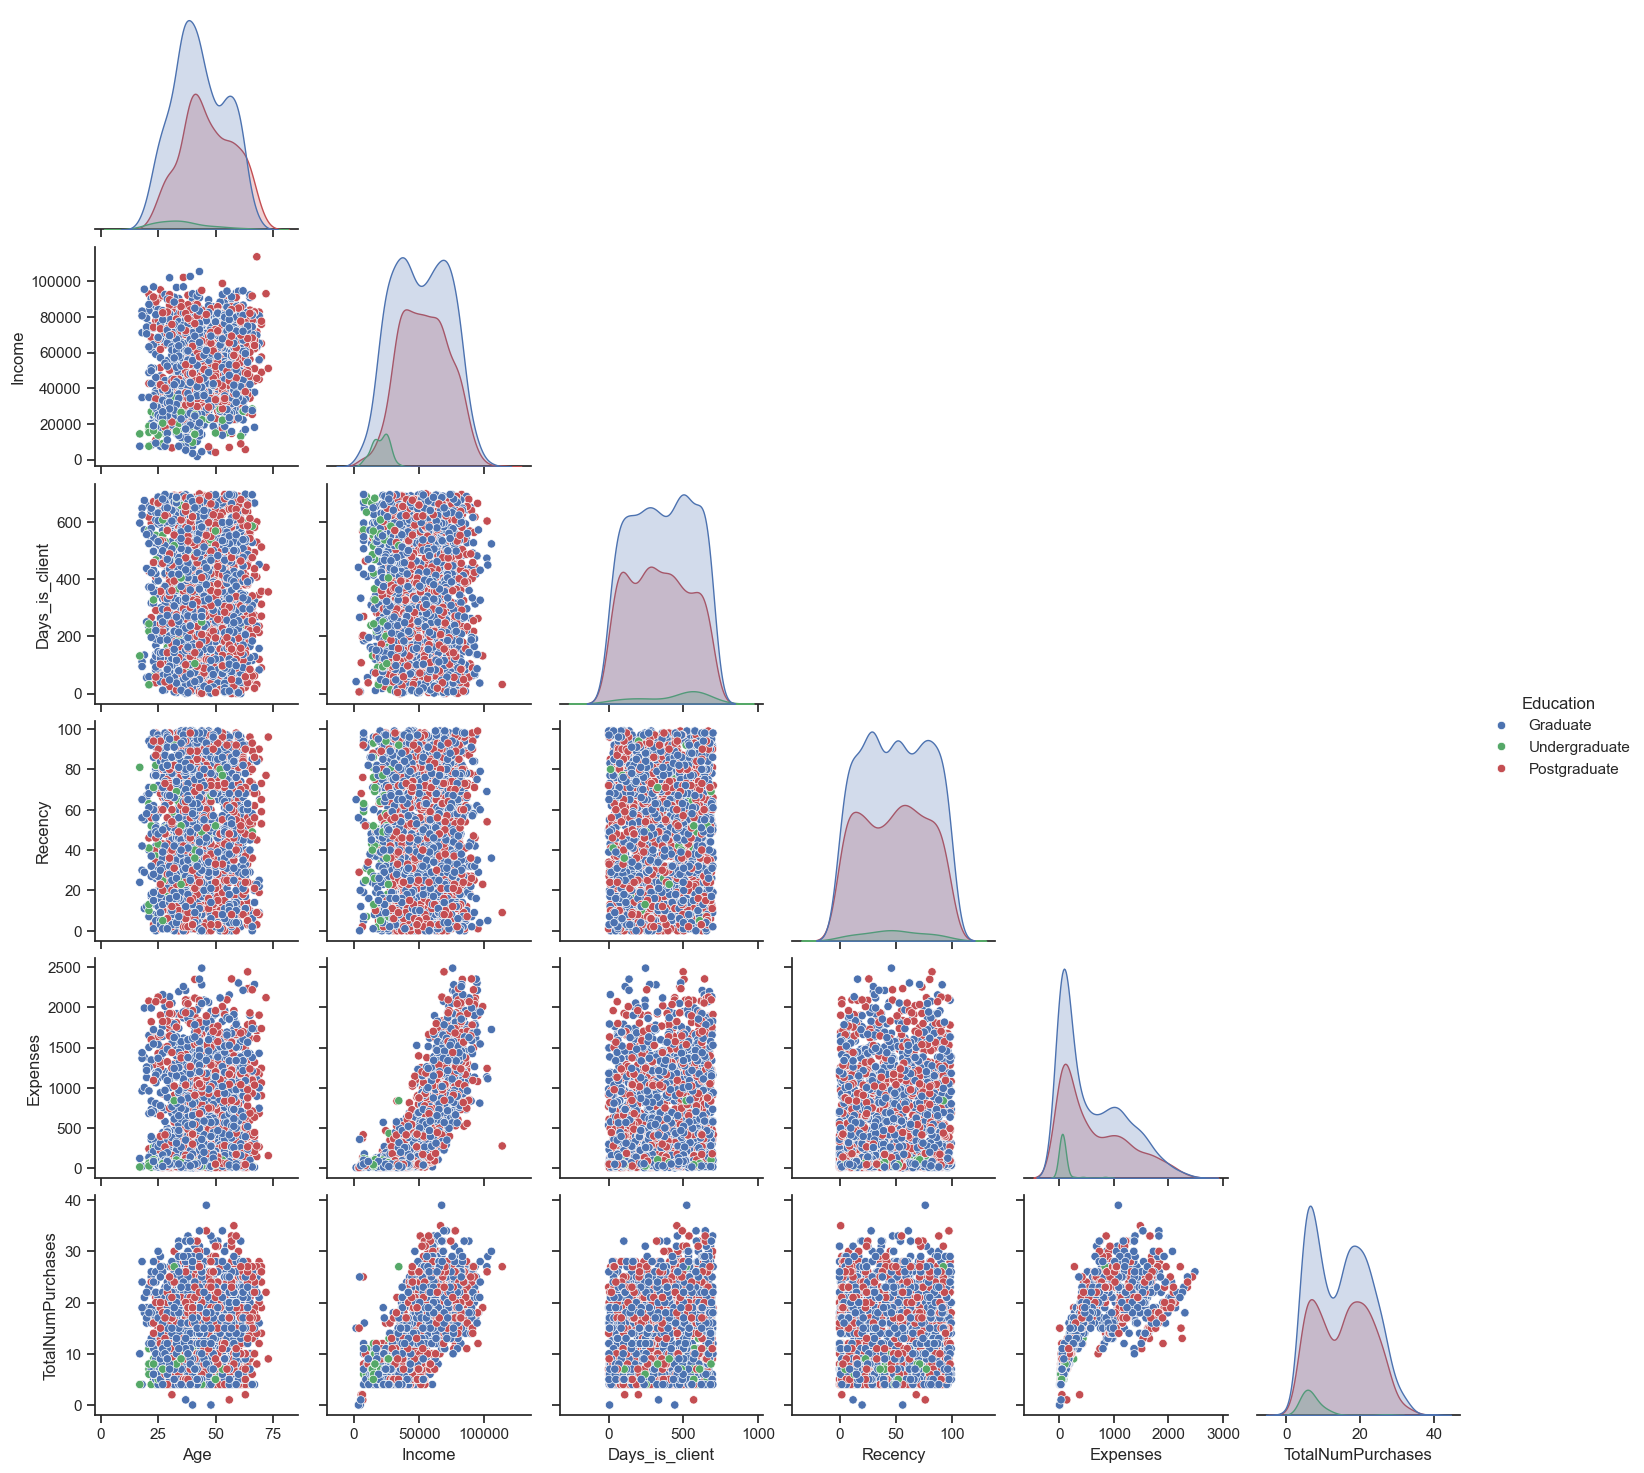

In [614]:
sns.pairplot(df[numerical_columns + ['Education']], hue='Education', corner=True, palette=palette_3)
plt.show()


**Key Insights from Bivariate PairPlot Analysis:**  

1. **Income drives spending and purchases:** Higher-income customers spend more and buy more frequently, making income the most influential variable for customer value.  

2. **Expenses & Total Purchases are tightly linked:** Customers who purchase more also spend more; these features capture similar behavior from different angles.  

3. **Education impacts purchasing behavior:** Graduates and Postgraduates dominate higher income, expenses, and purchases, while Undergraduates are mostly lower across all three.  

4. **Age has limited effect:** Income-adjusted behavior is similar across age groups; age alone is not a strong predictor.  

5. **Recency and client duration matter less:** Recent customers or long-term clients do not consistently spend more; value depends on income and engagement rather than temporal factors.  

6. **Non-linear patterns exist:** Education classes overlap in 2D projections, suggesting non-linear methods may better separate groups.  


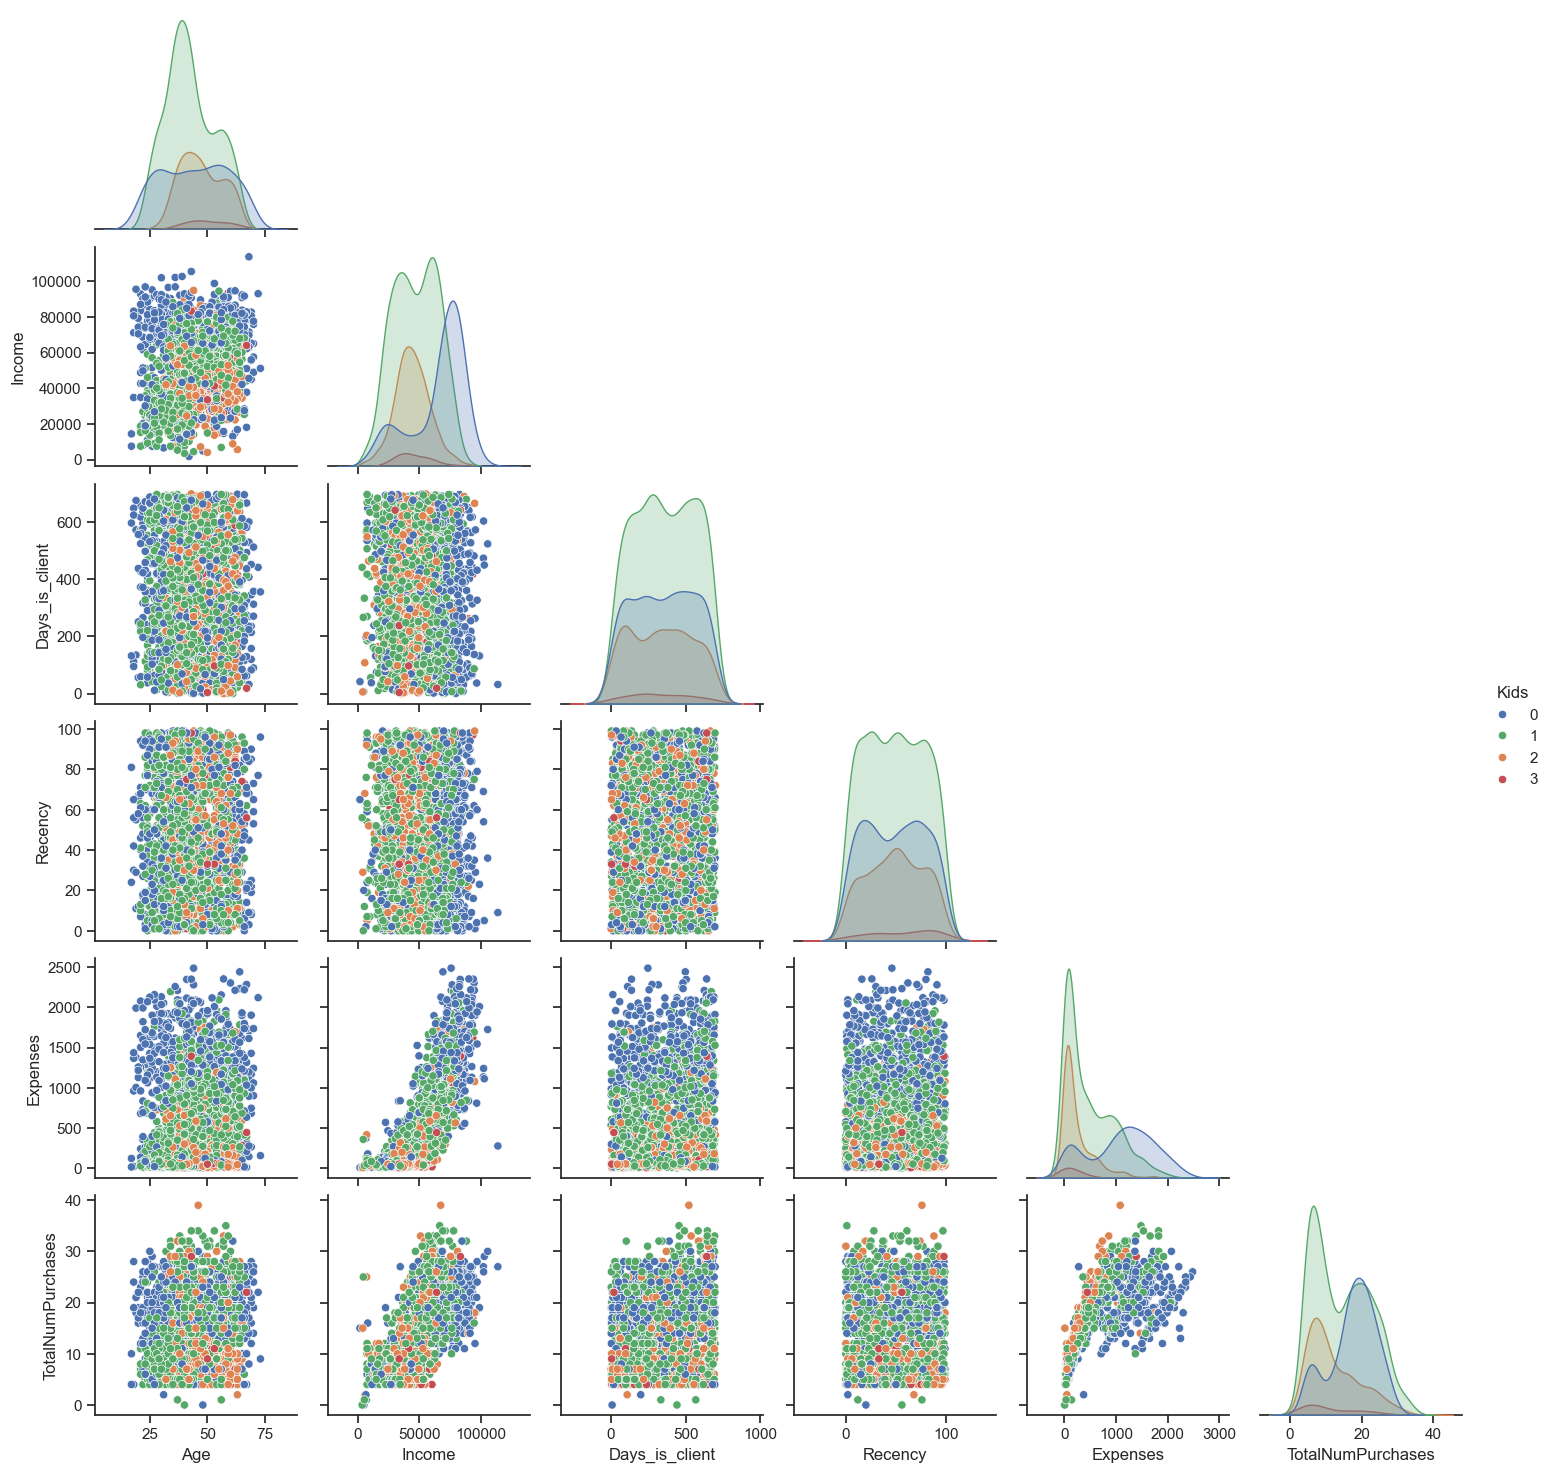

In [615]:
sns.pairplot(df[numerical_columns + ['Kids']], hue='Kids', corner=True, palette=palette_4)
plt.show()

**Key Insights: Impact of Number of Kids on Customer Behavior**  

1. **Income decreases as number of kids increases:**  
Customers with 0 kids are concentrated in higher income ranges, 1–2 kids have moderate income, and 3 kids are mostly lower income.  

2. **Spending drops with more kids:**  
Expenses are highest for 0 kids and gradually decrease as the number of kids rises. Larger families have lower discretionary spending.  

3. **Purchase frequency declines with household size:**  
TotalNumPurchases is highest for 0 kids, slightly lower for 1 kid, and noticeably lower for 2–3 kids.  

4. **Income → Expenses → Purchases chain persists:**  
Regardless of kids, higher income leads to higher expenses and purchases; number of kids shifts customers along this curve rather than changing it.  

5. **Age is not a strong factor:**  
All kid categories appear across a wide age range; age alone does not explain family size or spending.  

6. **Recency and client duration independent of kids:**  
Days_is_client and Recency show similar distributions across all family sizes.  

7. **Segmentation potential:**  
- High-value: 0 kids, high income, high expenses, frequent purchases  
- Mid-value: 1–2 kids, moderate income and purchases  
- Low-value: 3 kids, low income and low spending  

**Summary:** Fewer kids → higher income, more spending, and more purchases; larger families spend less despite similar engagement duration.


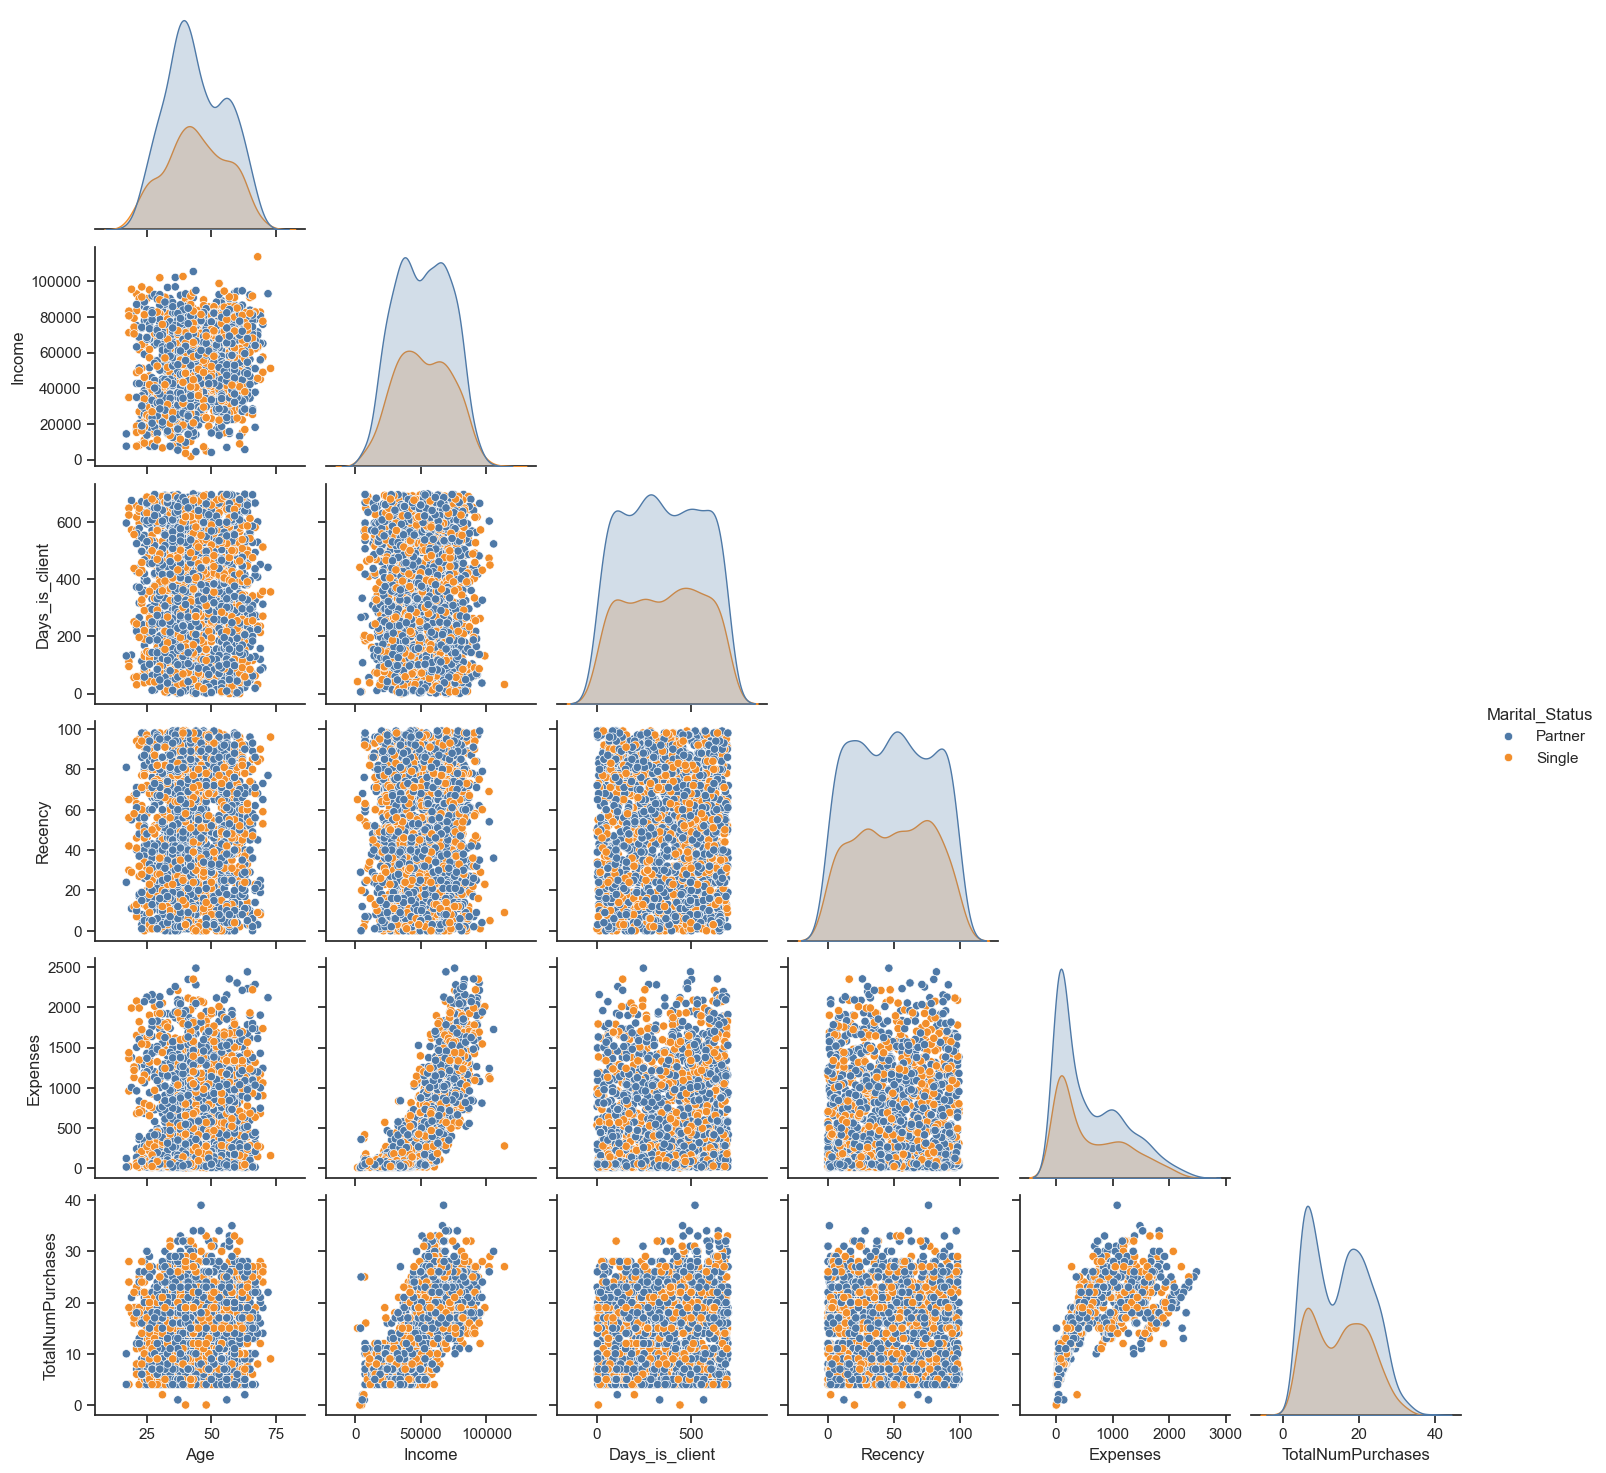

In [616]:
sns.pairplot(df[numerical_columns + ['Marital_Status']], hue='Marital_Status', corner=True, palette=palette_2)
plt.show()

**Key Insights: Impact of Marital Status on Customer Behavior**  

1. **Partnered customers tend to have higher income:**  
Income distribution for customers with a partner is shifted toward higher values, while singles concentrate in lower to mid-income ranges.  

2. **Spending is higher for partnered customers:**  
Expenses are generally higher for those with a partner, likely due to dual income or shared financial responsibility.  

3. **Purchase frequency is higher among partnered customers:**  
TotalNumPurchases is higher on average for partnered customers; singles make fewer purchases.  

4. **Core income → spending → purchases relationships persist:**  
Marital status shifts customers along the same spending curve: higher income still leads to higher expenses and more purchases.  

5. **Age is not a strong differentiator:**  
Both singles and partnered customers span similar age ranges; age is secondary to income and household structure.  

6. **Engagement timing is independent of marital status:**  
Recency and Days_is_client show similar distributions for both groups; marital status does not affect interaction timing.  

7. **Segmentation potential:**  
- High-value: Partnered, higher income, higher expenses, frequent purchases  
- Low-value: Single, lower income, lower expenses, fewer purchases  

**Summary:** Customers with a partner earn more, spend more, and purchase more frequently, while recency and loyalty duration remain similar across marital statuses.


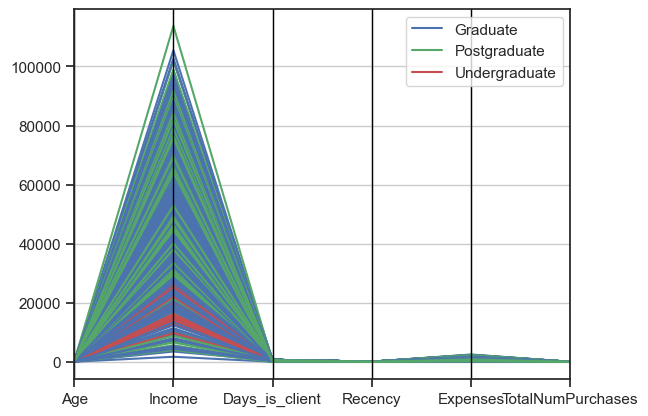

In [617]:
df_pc = df[numerical_columns + ['Education']]
parallel_coordinates(df_pc, 'Education', color=palette_3)
plt.show()

**Key Insights: Customer Behavior by Education Level (Parallel Coordinates)**

1. **Income is the strongest differentiator:**  
Postgraduates consistently earn the most, Graduates are in the middle, and Undergraduates earn the least. Education strongly impacts earning power.

2. **Spending scales with education:**  
Expenses increase from Undergraduates → Graduates → Postgraduates, mirroring income levels. Higher education corresponds to higher spending capacity.

3. **Purchase frequency rises with education:**  
TotalNumPurchases is highest for Postgraduates, moderate for Graduates, and lowest for Undergraduates. Education affects both engagement and buying activity.

4. **Age is not a discriminating factor:**  
Lines overlap heavily across all education groups for Age. Differences in behavior are not explained by age once education is considered.

5. **Loyalty and recency are similar:**  
Days_is_client and Recency show strong overlap for all education levels. Education does not influence engagement timing.

6. **Overall customer profiles by education:**  
- Undergraduate → low income, low expenses, low purchases  
- Graduate → moderate income, moderate spending and activity  
- Postgraduate → high income, high expenses, high purchase frequency

**Summary:** Education primarily drives income, which in turn affects expenses and purchase behavior, while age and engagement duration remain largely unchanged.


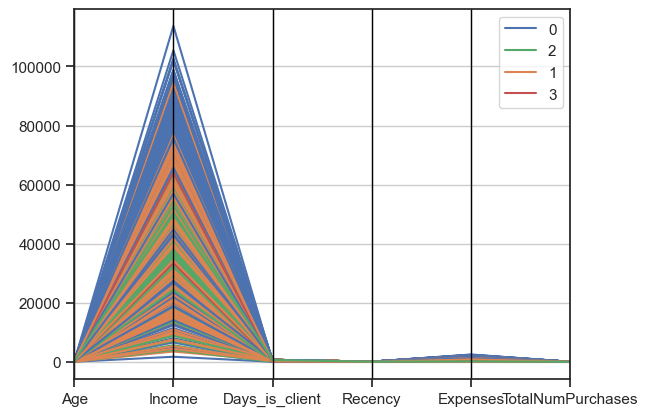

In [618]:
df_pc = df[numerical_columns + ['Kids']]
parallel_coordinates(df_pc, 'Kids',color=palette_4)
plt.show()

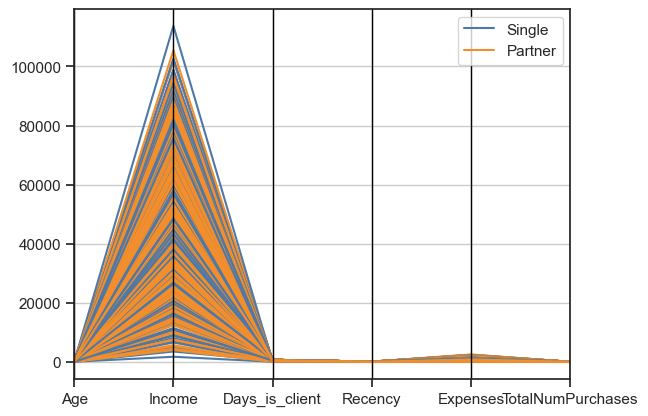

In [619]:
df_pc = df[numerical_columns + ['Marital_Status']]
parallel_coordinates(df_pc, 'Marital_Status',color=palette_2)
plt.show()

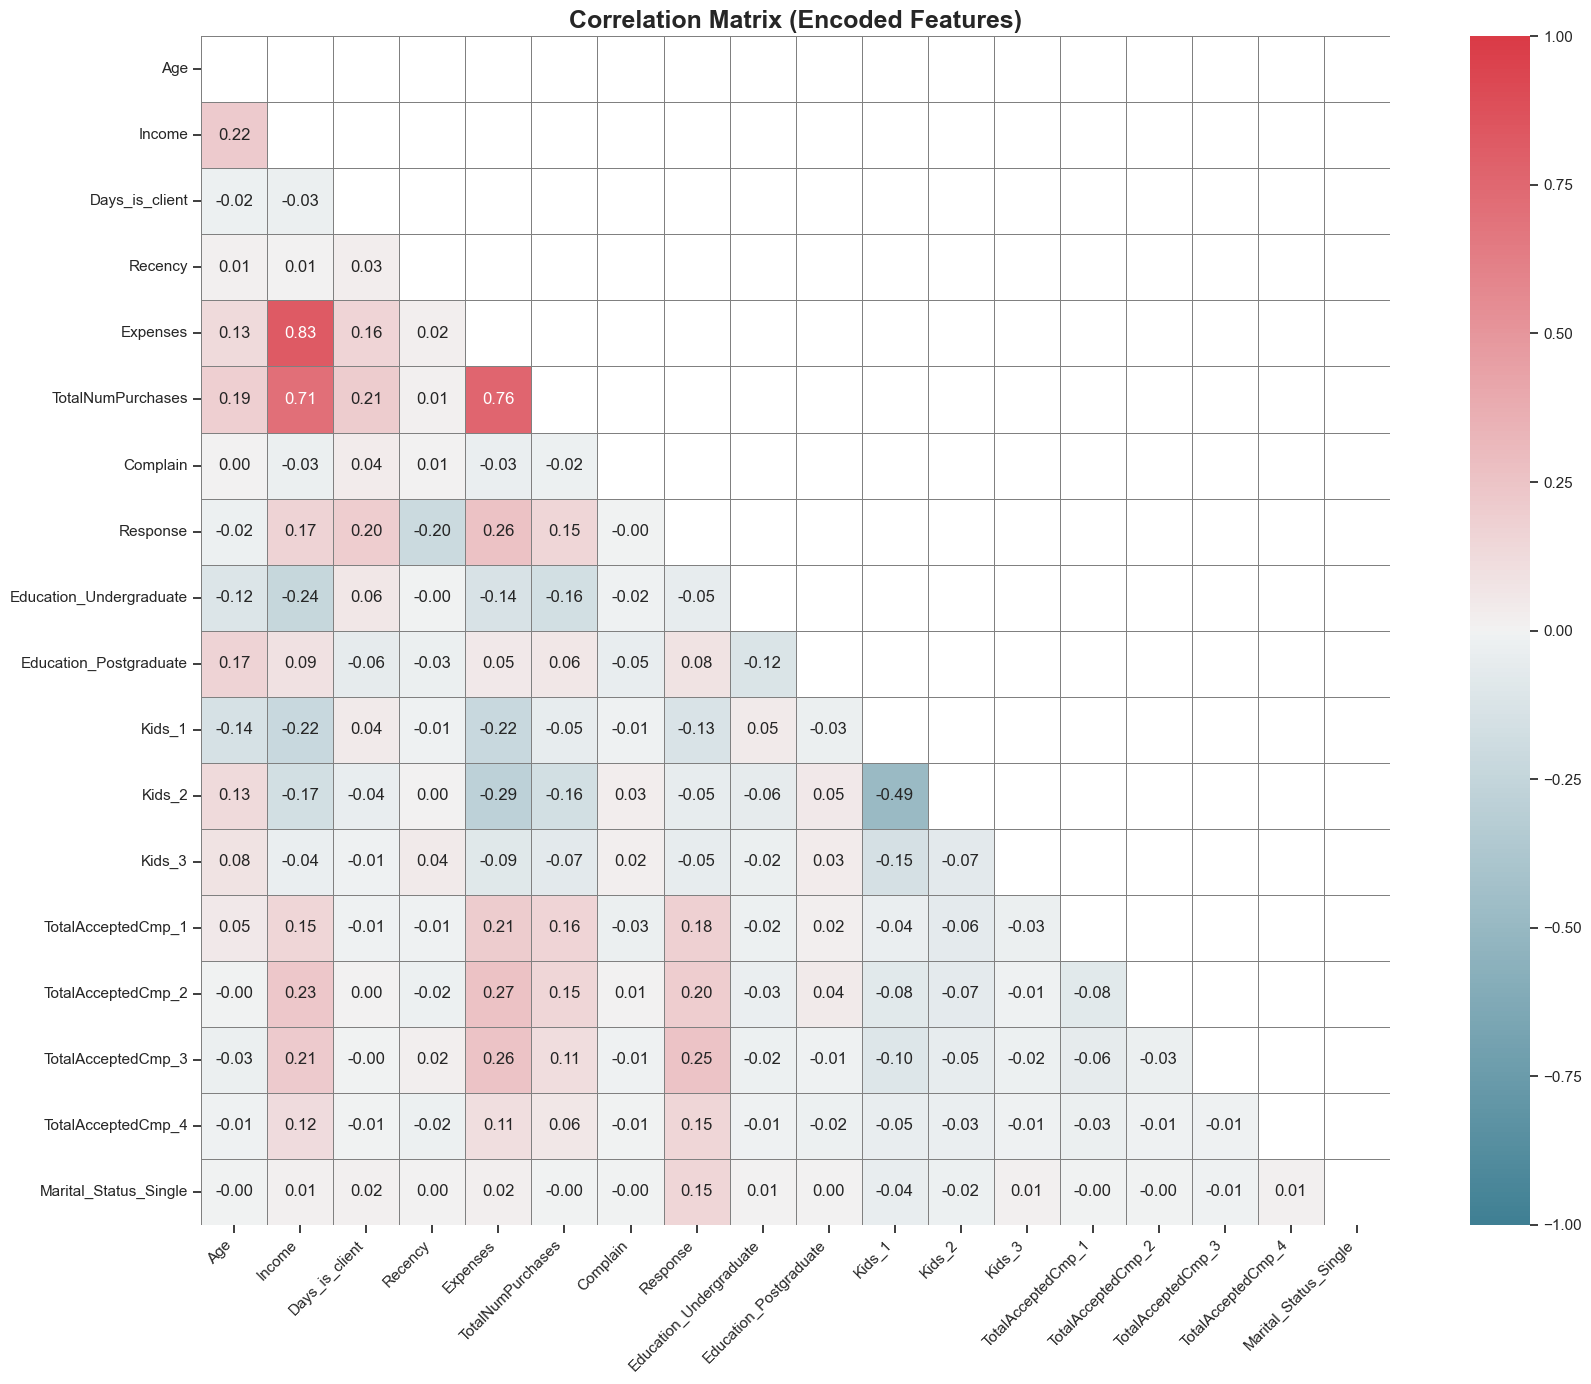

In [620]:
to_corr = [
    'Age', 'Income', 'Days_is_client', 'Recency', 'Expenses',
    'TotalNumPurchases', 'Complain', 'Response',

    'Education_Undergraduate', 'Education_Postgraduate',

    'Kids_1', 'Kids_2', 'Kids_3',

    'TotalAcceptedCmp_1', 'TotalAcceptedCmp_2',
    'TotalAcceptedCmp_3', 'TotalAcceptedCmp_4',

    'Marital_Status_Single'
]

to_corr = [col for col in to_corr if col in df_encoded.columns]

corr = df_encoded[to_corr].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

plt.figure(figsize=(18, 14))
plt.title('Correlation Matrix (Encoded Features)', fontsize=18, weight='bold')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    linecolor='gray',
    square=True
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Correlation Insights & Key Findings**

---

### 1️ Income, Expenses, Purchases
* Strong positive correlations:  
  - Income ↔ Expenses: 0.83  
  - Income ↔ TotalNumPurchases: 0.71  
  - Expenses ↔ TotalNumPurchases: 0.76  
* **Takeaway:** High-income customers spend more and buy more; these three variables capture core customer value.

---

### 2️ Campaign Response
* Response ↔ Expenses: 0.26  
* Response ↔ Income: 0.17  
* Response ↔ TotalNumPurchases: 0.15  
* Response ↔ Recency: –0.20  
* **Takeaway:** Customers who spend and buy more, and recent buyers, respond more to campaigns.

---

### 3️ Minor Influences
* Age, Days_is_client, Marital status, Complaints: weak correlations  
* Education & Kids: small effects  
* **Takeaway:** These features have limited impact on spending or response.

---

### 4️ Campaign Loyalty
* Past campaign responses positively correlated  
* **Takeaway:** Customers who respond once are more likely to respond again.


----
# 11. Scaling & Dimensionality Reduction
---

We applied PCA for dimensionality reduction to simplify the data, improve model performance, and speed up computation. Beforehand, we scaled the data since PCA is sensitive to feature scaling

In [621]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_encoded)

In [622]:
pca = PCA()
pca.fit(df_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


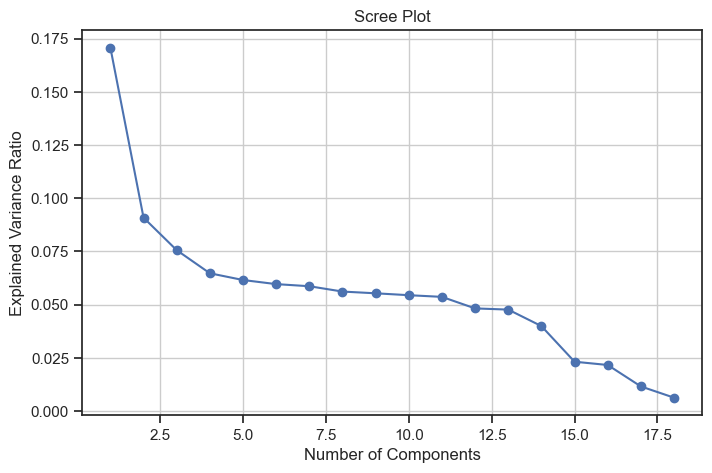

In [623]:
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()


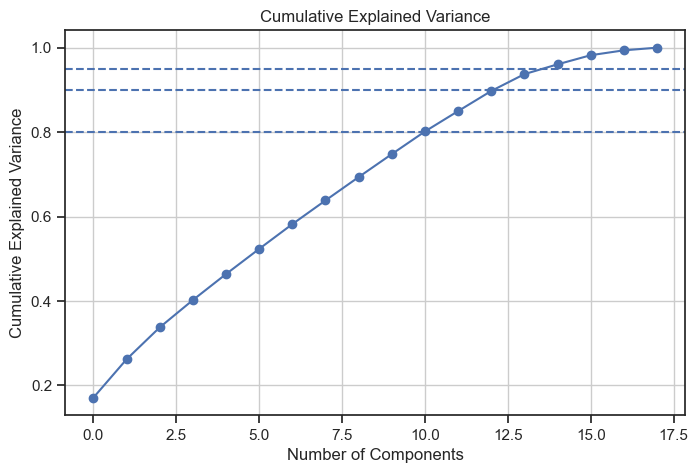

In [624]:
plt.figure(figsize=(8, 5))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.80, linestyle='--')
plt.axhline(y=0.90, linestyle='--')
plt.axhline(y=0.95, linestyle='--')
plt.grid(True)
plt.show()


From the scree plot, we chose to keep 10 components, which explain 80% of the cumulative variance—sufficient for the next analysis.

In [625]:
pca_final = PCA(n_components=10)
X_pca = pca_final.fit_transform(df_scaled)


---
# 12. t-SNE Visualization
---

In [626]:
tsne = TSNE(
    n_components=2,
    init='pca',
    perplexity=30,
    learning_rate='auto',
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

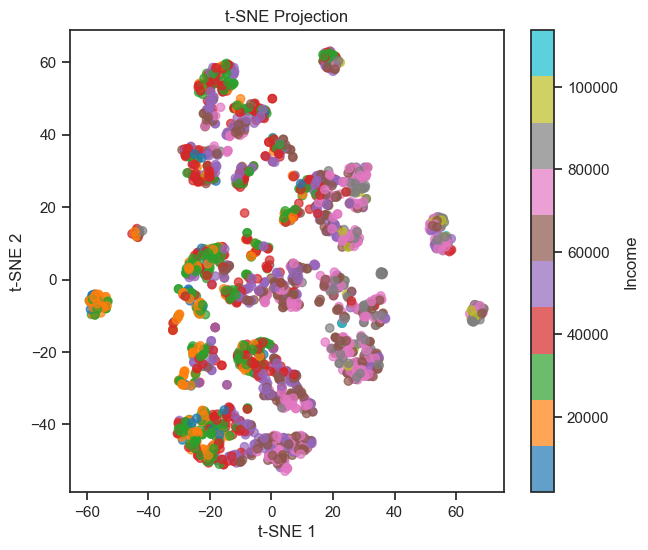

In [627]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['Income'],
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection")
plt.colorbar(label="Income")
plt.show()


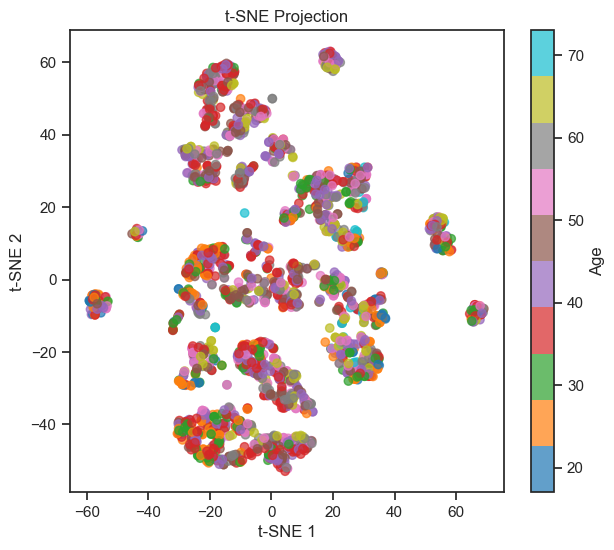

In [628]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['Age'],
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection")
plt.colorbar(label="Age")
plt.show()

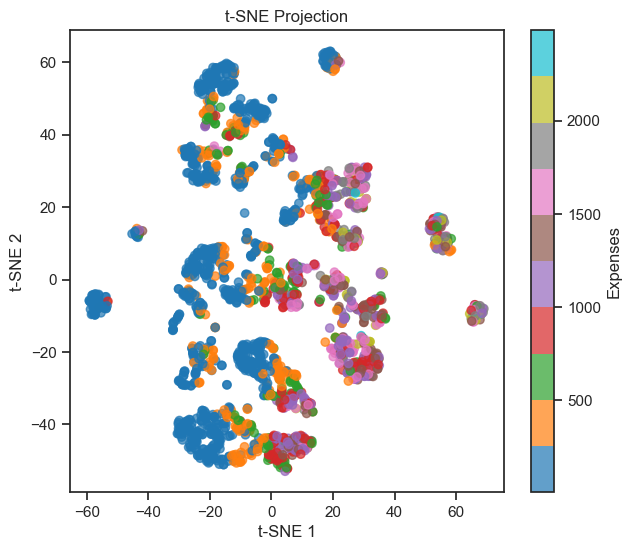

In [629]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['Expenses'],
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection")
plt.colorbar(label="Expenses")
plt.show()

From the t-SNE plots, we can faintly observe potential clusters in the data, though they are not very clear. We will proceed with clustering and then visualize the results to identify clearer groupings

---
# 13. Customer Segmentation Using K-Means
---

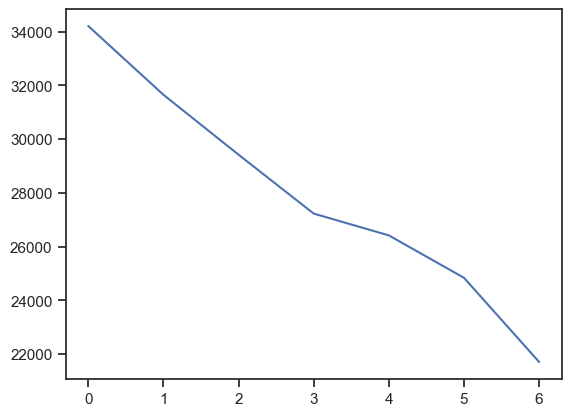

In [630]:
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=101)
    kmeans.fit(df_scaled)
    
    ssd.append(kmeans.inertia_)
    
plt.plot(ssd)
plt.show()

Using the Elbow method, we evaluated different numbers of clusters (2–8) and observed that the curve starts to bend at 3 clusters. This suggests that 3 is an appropriate number of clusters for our KMeans analysis.

In [631]:
kmeans = KMeans(n_clusters=3, max_iter=10000, random_state=42)

kmeans.fit(X_pca)

y_kmeans = kmeans.fit_predict(X_pca)

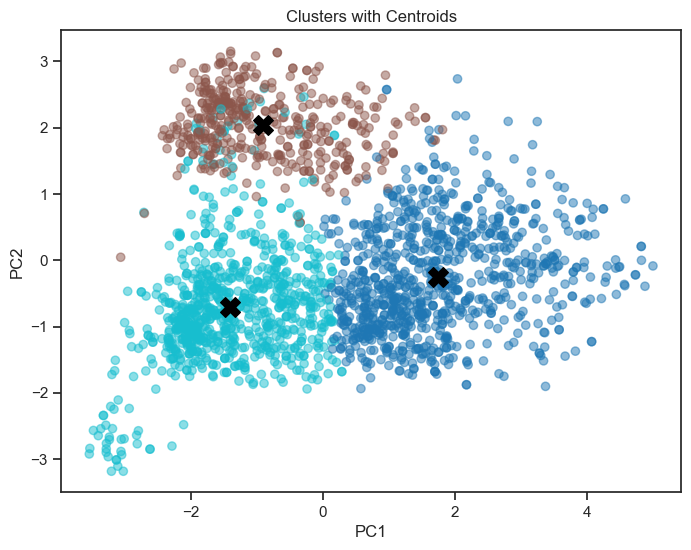

In [633]:
centroids = kmeans.cluster_centers_  
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap='tab10', alpha=0.5)
plt.scatter(centroids[:,0], centroids[:,1], c='black', s=200, marker='X')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters with Centroids')
plt.show()


After applying KMeans clustering, we visualized the clusters along with their centroids. The clusters are well-separated with very few overlapping points, indicating that the clustering is effective and meaningful.

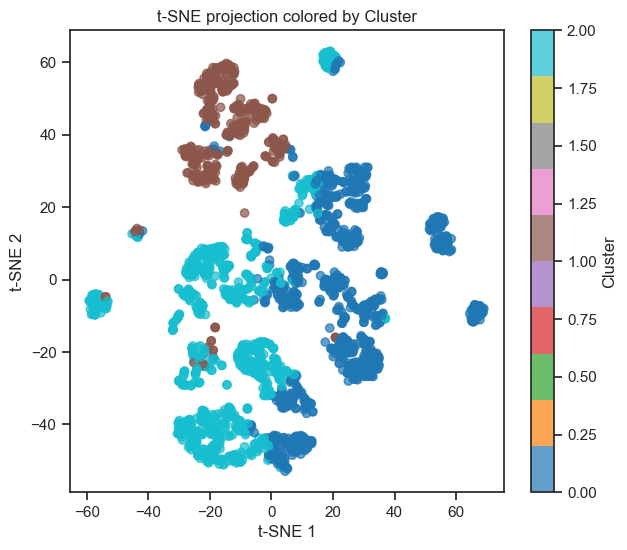

In [634]:
plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_kmeans, cmap='tab10', alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection colored by Cluster")
plt.colorbar(label="Cluster")
plt.show()


After clustering, the t-SNE projection shows much clearer and more distinct clusters, confirming that the segmentation captures meaningful differences between customer groups

---
# 14. Cluster Profiling & Interpretation
---

In [ ]:
cluster_summary = df.groupby('Clusters').agg(
    Age=('Age', 'mean'),
    Income=('Income', 'mean'),
    Days_is_client=('Days_is_client', 'mean'),
    Expenses=('Expenses', 'mean'),
    TotalNumPurchases=('TotalNumPurchases', 'mean'),
    TotalAcceptedCmp=('TotalAcceptedCmp', 'mean'),
    Complain=('Complain', 'mean'),
    Response=('Response', 'mean')
)
display(cluster_summary)


,Age,Income,Days_is_client,Expenses,TotalNumPurchases,TotalAcceptedCmp,Complain,Response
Clusters,,,,,,,,
0,46.452250,70542.718750,377.664105,1200.354555,21.547750,0.604830,0.004391,0.238200
1,48.004866,43415.785156,328.885645,213.031630,11.727494,0.097324,0.017032,0.104623
2,39.817654,35507.144531,338.777003,159.087108,9.307782,0.073171,0.010453,0.081301


: 

In [637]:
def graph_builder(df, num_cols, object_cols, binary_cols=None):

    sns.set_style('darkgrid')  

    n_cols = len(num_cols)
    rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(25, 5 * rows))
    axes = axes.ravel()

    for i, col in enumerate(num_cols):
        sns.boxplot(
            data=df,
            x="Clusters",
            y=col,
            palette="Paired",
            ax=axes[i]
        )
        axes[i].set_xlabel("Clusters", fontsize=14)
        axes[i].set_ylabel(col, fontsize=14)
        axes[i].set_title(f"{col} by Cluster", fontsize=16)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(rows, 3, figsize=(25, 5 * rows))
    axes = axes.ravel()

    for i, col in enumerate(num_cols):
        sns.histplot(
            data=df,
            x=col,
            hue="Clusters",
            multiple="stack",
            kde=True,
            palette="Paired",
            ax=axes[i]
        )
        axes[i].set_xlabel(col, fontsize=14)
        axes[i].set_ylabel("Count", fontsize=14)
        axes[i].set_title(f"{col} Distribution by Cluster", fontsize=16)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    all_object_cols = object_cols.copy()
    if binary_cols is not None:
        all_object_cols += binary_cols 

    n_cols = len(all_object_cols)
    rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(25, 5 * rows))
    axes = axes.ravel()

    for i, col in enumerate(all_object_cols):
        sns.countplot(
            data=df,
            x=col,
            hue="Clusters",
            palette="Paired",
            ax=axes[i]
        )
        axes[i].set_xlabel(col, fontsize=14)
        axes[i].set_ylabel("Count", fontsize=14)
        axes[i].set_title(f"{col} Count by Cluster", fontsize=16)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


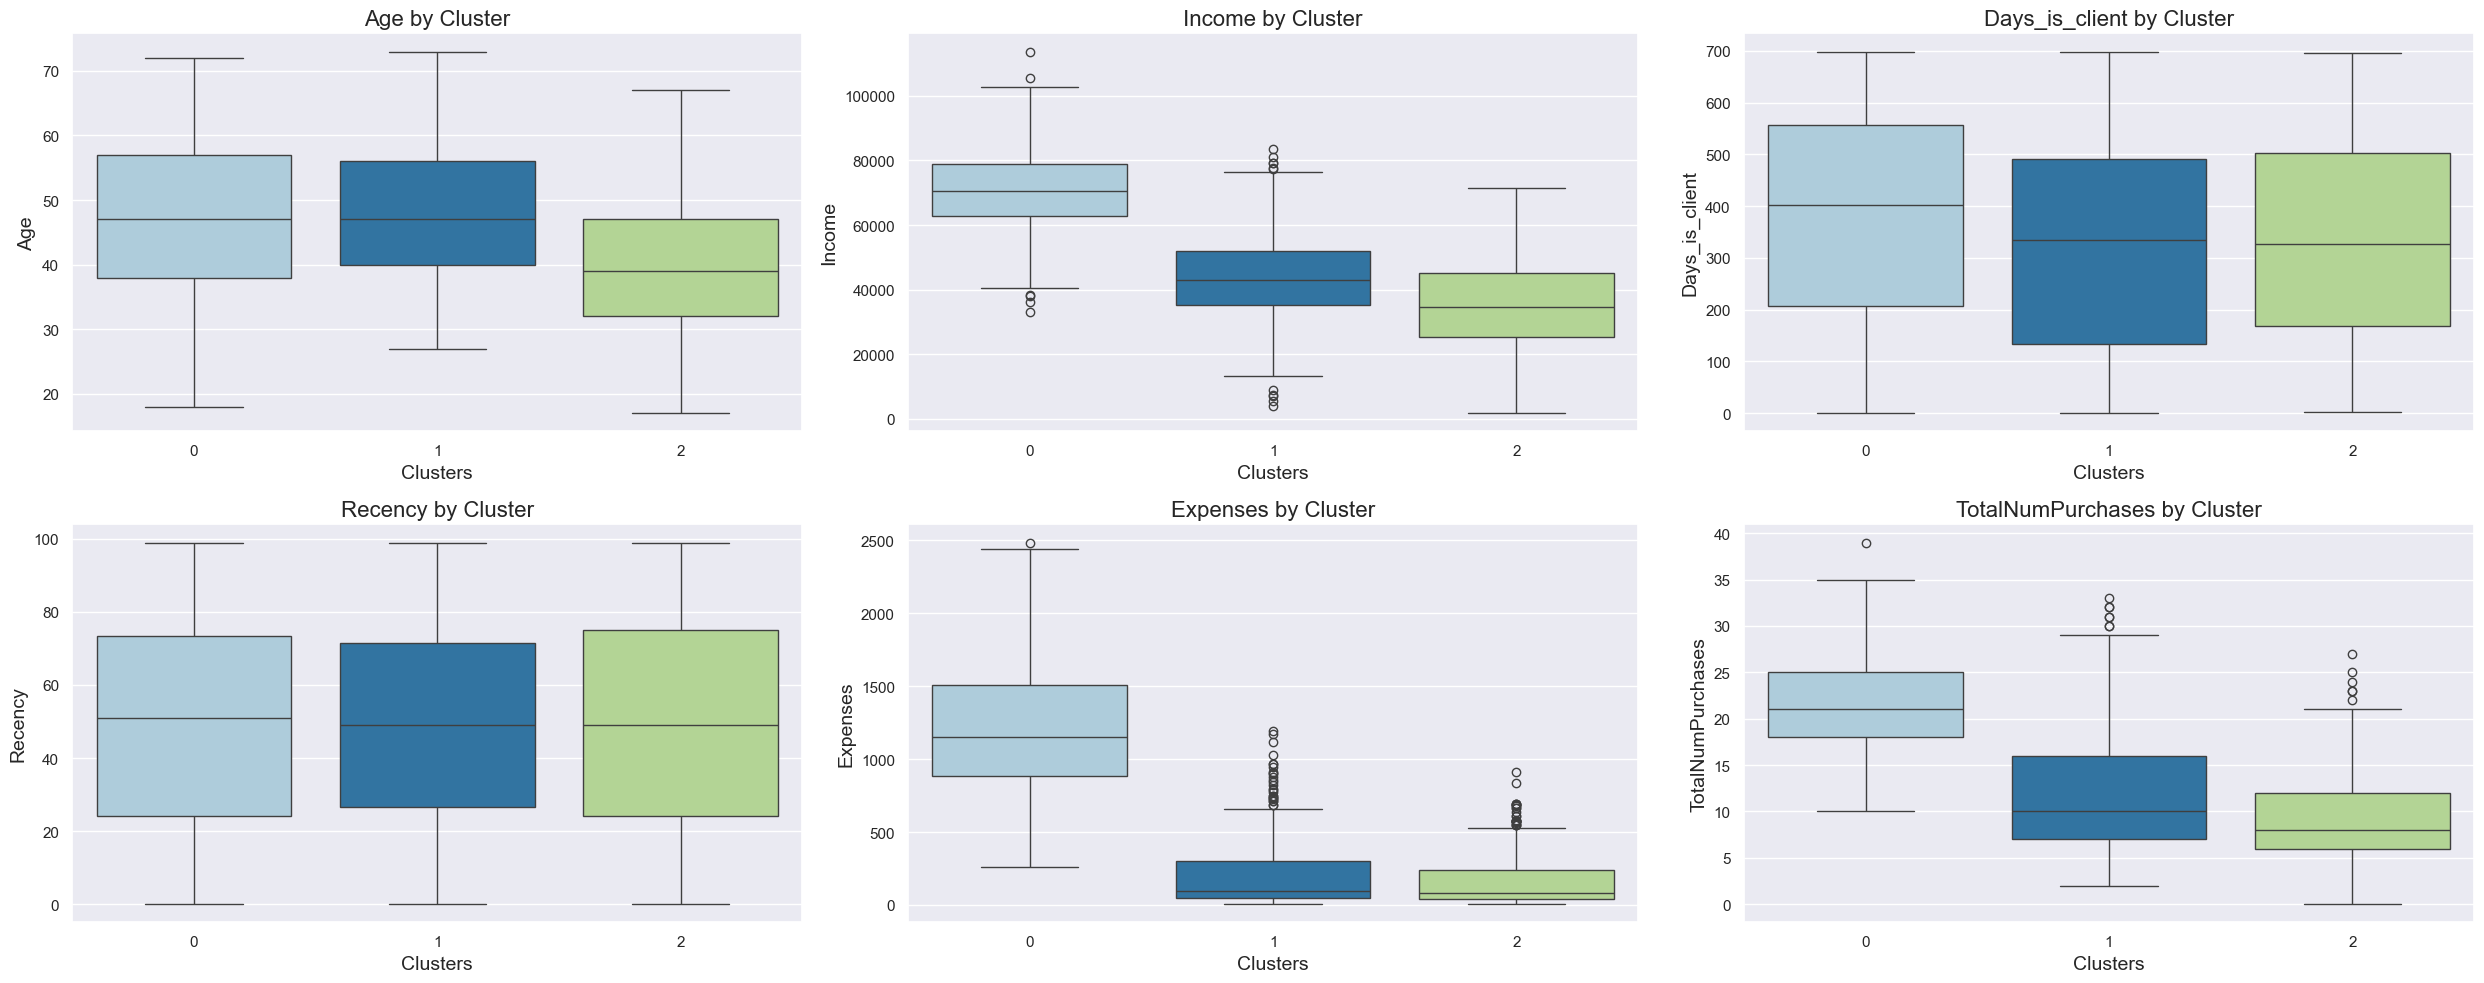

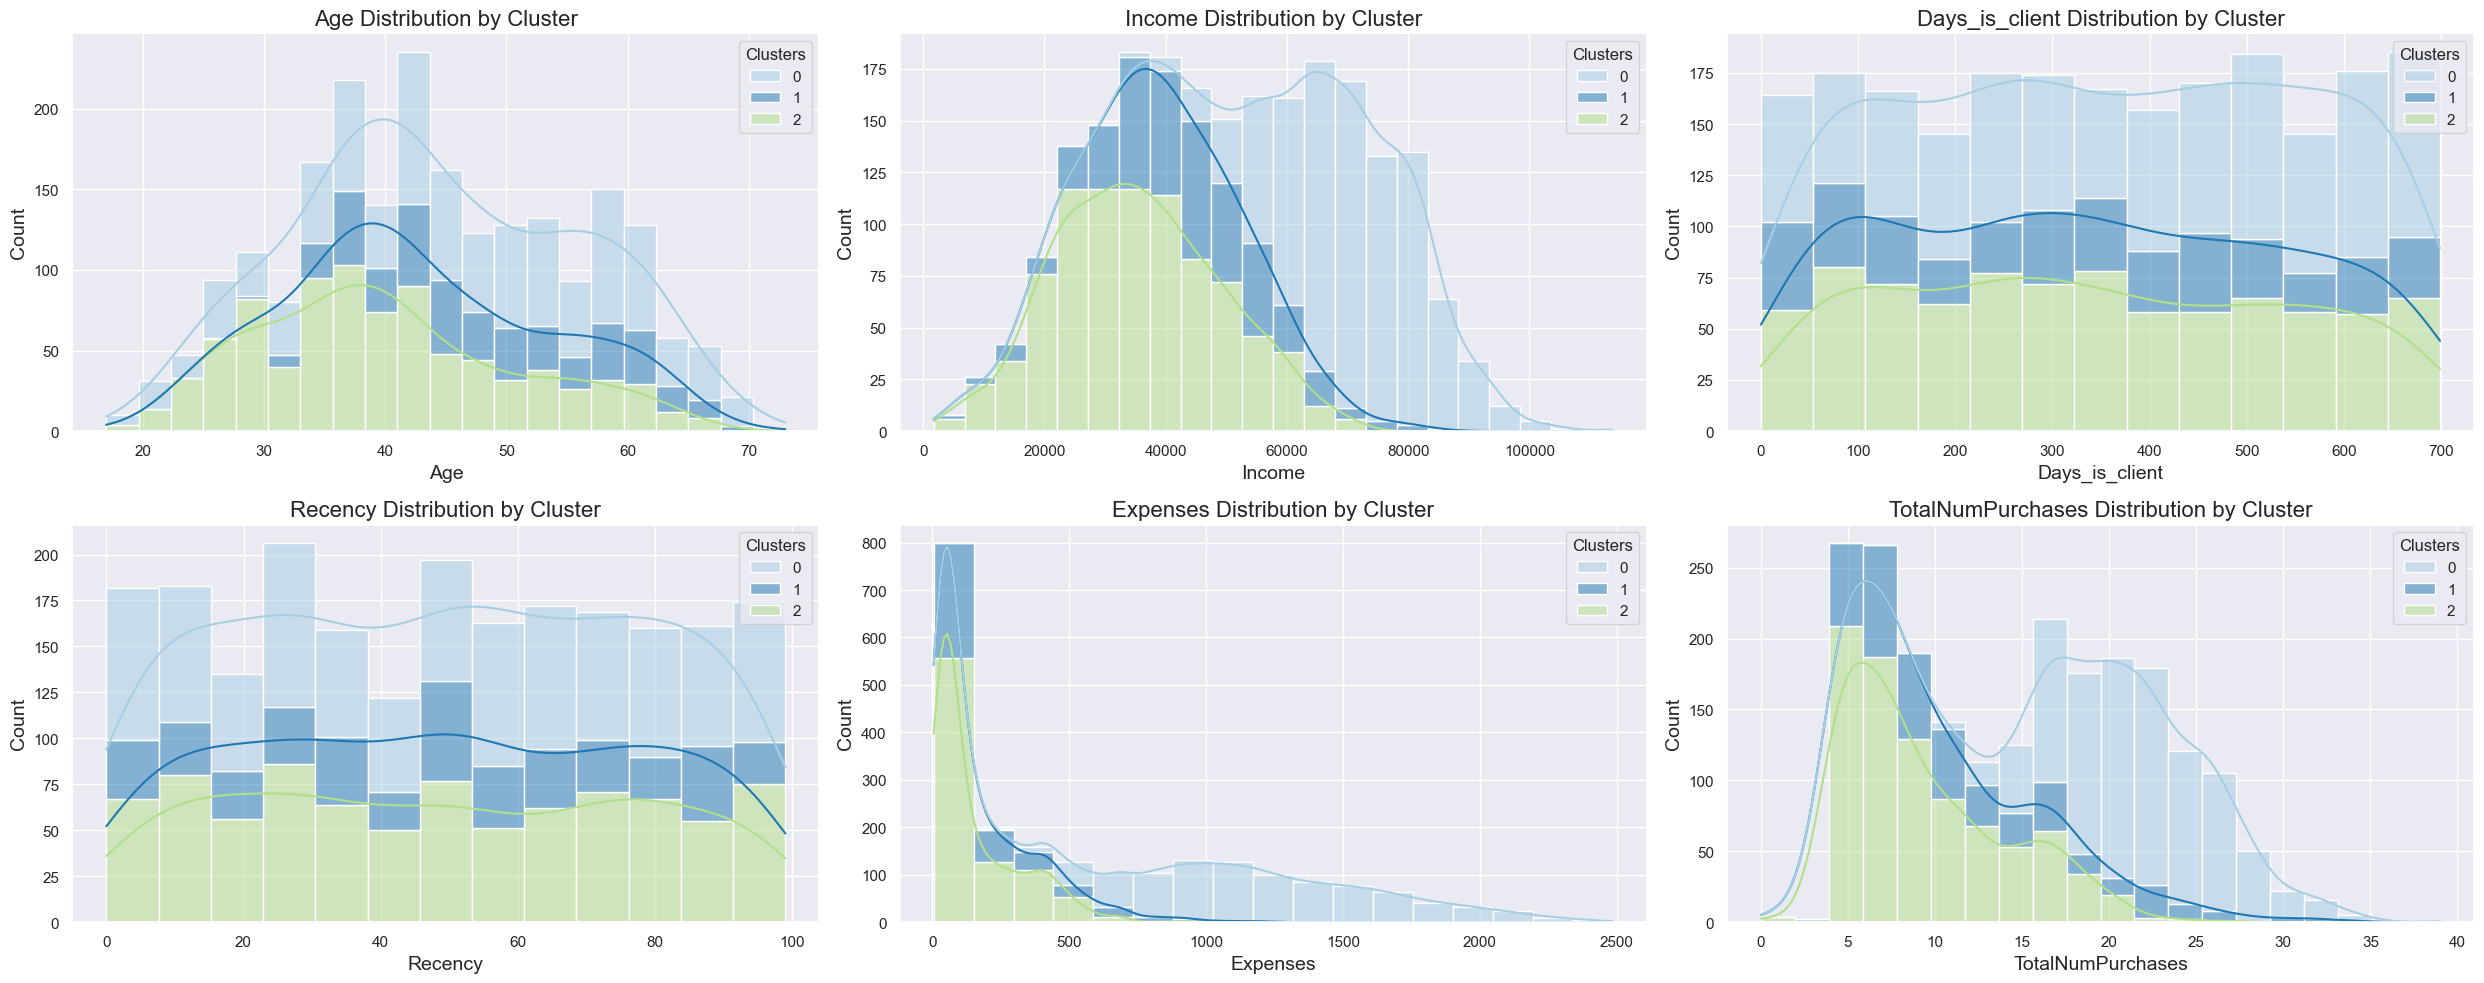

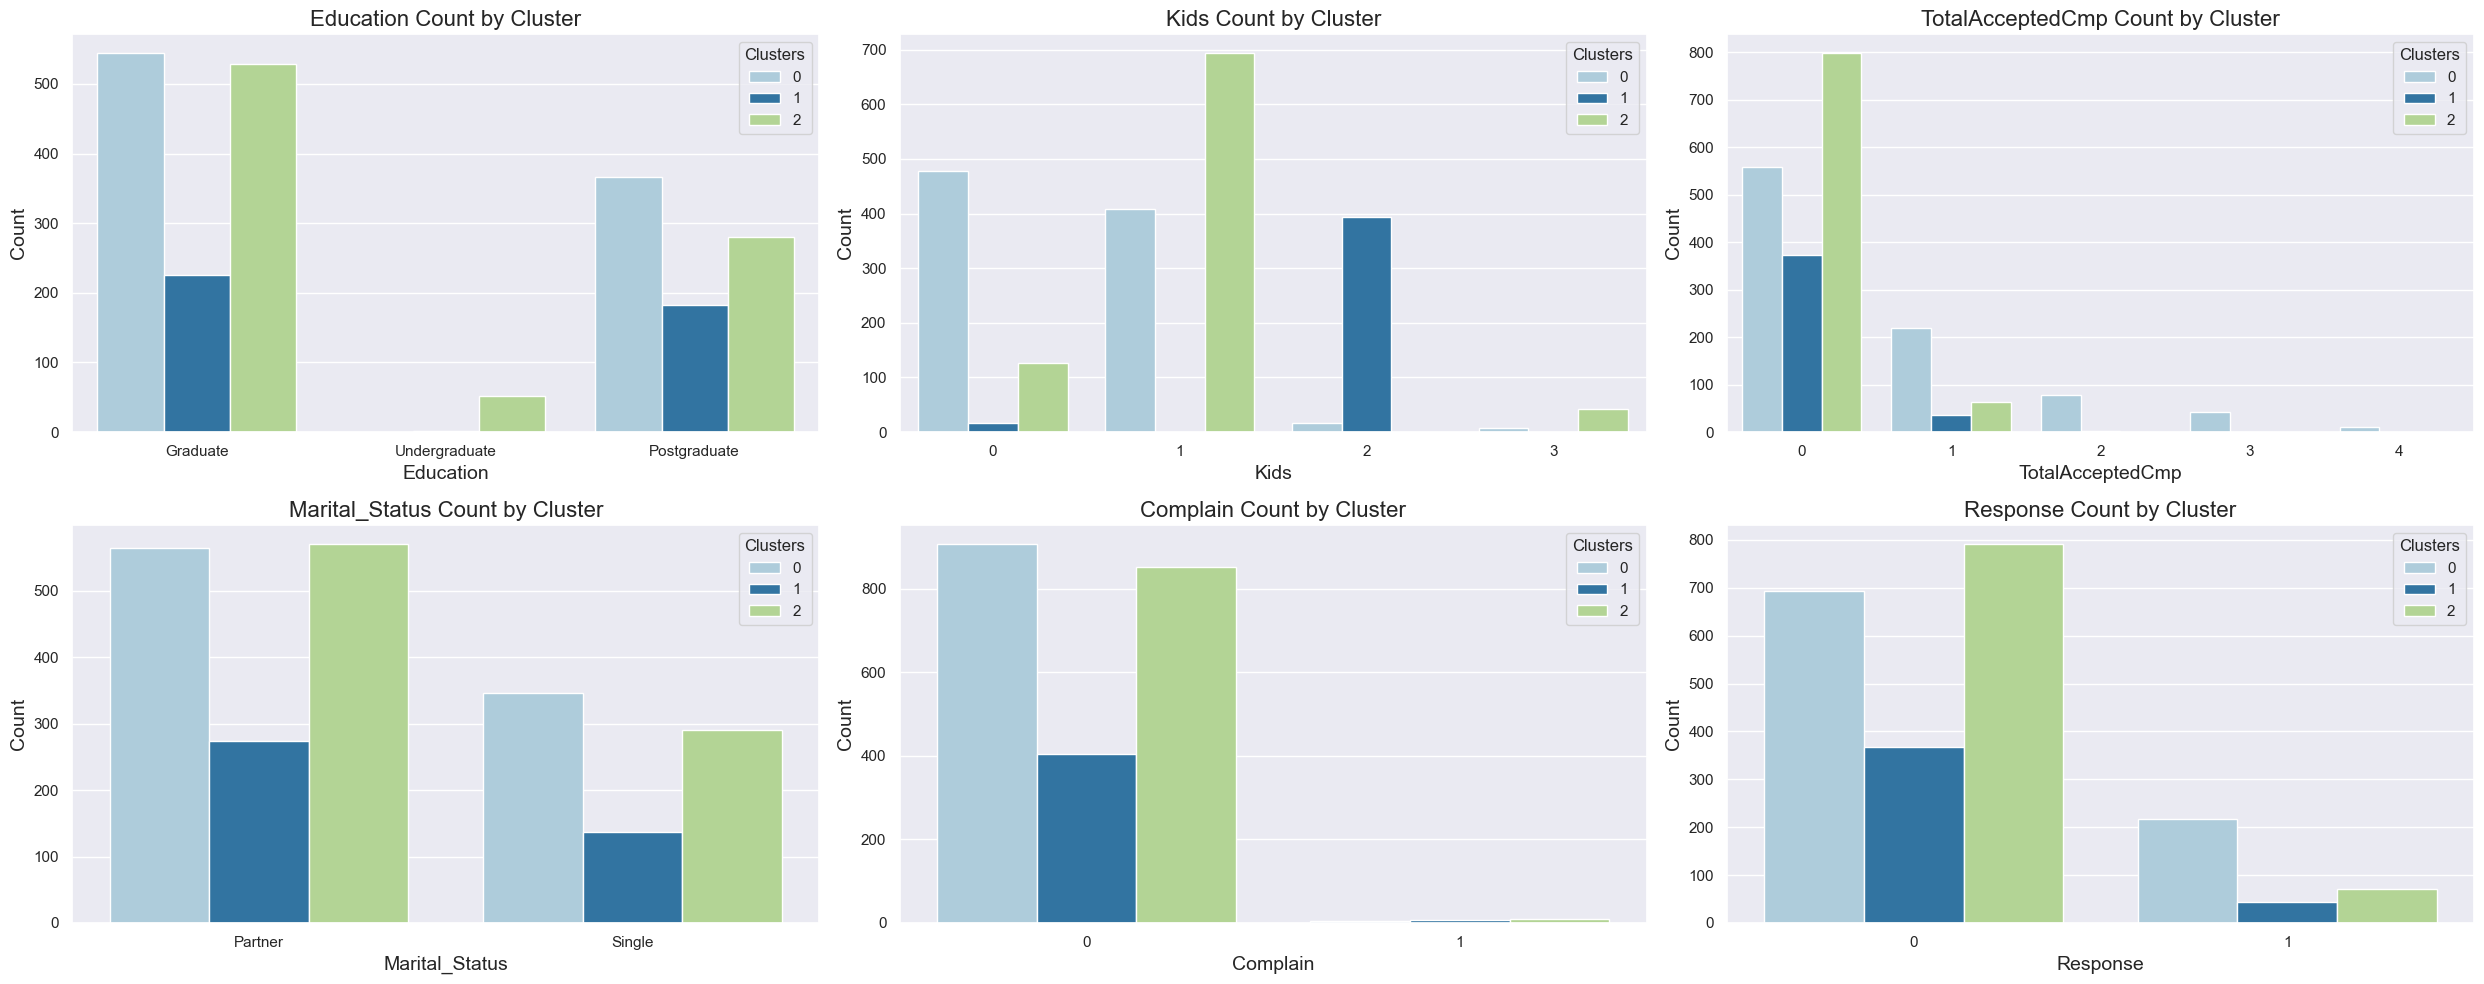

In [638]:
df['Clusters'] = y_kmeans  

graph_builder(
    df,
    num_cols=numerical_columns,
    object_cols=categorical_columns,
    binary_cols=binary_columns 
)


### Cluster Insights

---

#### Cluster 0 – High-Value Loyal Customers (VIPs)

**Profile & Demographics**
- **Age:** 45–60 (middle-aged to older)  
- **Income:** Very high (~65k–80k+)  
- **Customer tenure (Days_is_client):** Longest  
- **Family:** Mostly partnered, 0–1 kids  

**Behavior & Spending**
- **Total expenses:** High (median ~1,200–1,500)  
- **Purchase frequency:** Highest (median ~20–25)  
- **Shopping behavior:** Regular buyers, comfortable with premium pricing  

---

#### Cluster 1 – Mid-Value Growth Customers

**Profile & Demographics**
- **Age:** 40–55  
- **Income:** Medium (~40k–50k)  
- **Customer tenure:** Medium  
- **Family:** Mixed marital status, 1–2 kids  

**Behavior & Spending**
- **Total expenses:** Moderate (median ~200–250)  
- **Purchase frequency:** Moderate (median ~10–12)  
- **Outliers:** Some higher spenders   

---

#### Cluster 2 – Low-Value / Price-Sensitive Customers

**Profile & Demographics**
- **Age:** 30–45 (youngest cluster)  
- **Income:** Lowest (~25k–35k)  
- **Customer tenure:** Short  
- **Family:** Mostly single or 0–1 kids  

**Behavior & Spending**
- **Total expenses:** Low (median ~50–100)  
- **Purchase frequency:** Few (median ~5–10)  
- **Shopping behavior:** Price-sensitive, casual buyers  


---
# 15. Customer Segmentation – Business Strategies & Actions
---
Based on the cluster analysis, here are actionable strategies for each customer segment:

---

###  **Cluster 0 – High-Value Loyal Customers (VIPs)**
1. Launch VIP loyalty programs with exclusive rewards.
2. Offer premium bundles and upsell high-margin products.
3. Personalized communication (emails, messages) to maintain engagement.
4. Provide early access to new products or services.
5. Organize events or webinars targeting high-value customers.

---

###  **Cluster 1 – Mid-Value Growth Customers**
6. Send targeted promotions and discounts to encourage upsell.
7. Create bundle offers to increase average order value.
8. Educational campaigns highlighting product benefits.
9. Use personalized recommendations based on past purchases.
10. Incentivize repeat purchases through loyalty points or cashback.

---

###  **Cluster 2 – Low-Value / Price-Sensitive Customers**
11. Offer entry-level products or starter packages.
12. Run low-cost, automated engagement campaigns (email/SMS).
13. Provide limited-time discounts to attract purchases.
14. Introduce onboarding campaigns to increase brand familiarity.
15. Focus on cost-effective retention, avoid high-expense campaigns.
